# Weekday and Weekend Divvy End-Station Patterns in Chicago

## Project Overview

**Research question:** How do weekday and weekend Divvy end-station patterns differ in Chicago, and what nearby urban service environments are associated with high-volume weekday and weekend destinations?

This notebook treats each Divvy **end station** as a destination proxy. A trip ending at a station is interpreted as demand for the nearby destination environment, not proof that the rider visited one specific place.

Main workflow:

Divvy trips -> cleaned end stations -> weekday/weekend aggregation -> Top 20 baseline -> spatial heatmaps -> coordinate-based OSM service profiles -> validation.

Weather is included as a secondary robustness check rather than the main research question.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = ROOT / "outputs"
FIGURE_DIR = ROOT / "figures"
DATA_OUTPUT_DIR = DATA_DIR / "outputs"

FINAL_OUTPUT_DIR = OUTPUT_DIR / "final_clean"
FINAL_FIGURE_DIR = FIGURE_DIR / "final_clean"
FINAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FINAL_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

OSM_RADIUS_MAIN = 250
RADIUS_LIST = [100, 250, 500]
TOPK_LIST = [20, 50, 100]
MAIN_PROFILE_TOP_K = 100
RANDOM_SEED = 42
N_SHUFFLES = 1000
N_BOOTSTRAPS = 1000
N_RANDOMIZATIONS = 1000
RUN_EXTRA_VALIDATION = True
RUN_TEMPORAL_HOLDOUT = False
FORCE_REBUILD = False
ENABLE_OSM_QUERIES = False
SAVE_FULL_CLEANED_TRIPS = False

pd.options.display.float_format = "{:,.4f}".format

print("Project root:", ROOT)
print("Final tables:", FINAL_OUTPUT_DIR)
print("Final figures:", FINAL_FIGURE_DIR)


Project root: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code
Final tables: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean
Final figures: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean


In [2]:
def first_existing_path(filename, *folders):
    candidates = [Path(folder) / filename for folder in folders]
    for path in candidates:
        if path.exists():
            return path
    tried = "\n".join(str(path) for path in candidates)
    raise FileNotFoundError(f"Missing {filename}. Tried:\n{tried}")


def read_cached_csv(filename, *folders, **kwargs):
    search_folders = folders or (OUTPUT_DIR, DATA_OUTPUT_DIR, DATA_DIR)
    path = first_existing_path(filename, *search_folders)
    print(f"Reading {filename} from {path}")
    return pd.read_csv(path, **kwargs)


def save_table(df, filename):
    path = FINAL_OUTPUT_DIR / filename
    df.to_csv(path, index=False)
    print("Saved table:", path)
    return path


def save_figure(filename, dpi=300):
    path = FINAL_FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print("Saved figure:", path)
    return path


def show_existing_image(filename, folder=FIGURE_DIR, width=760):
    path = Path(folder) / filename
    if not path.exists():
        print("Missing figure:", path)
        return None
    print("Existing figure:", path)
    display(Image(filename=str(path), width=width))
    return path


## Research Question and Hypothesis

**Destination proxy.** The public Divvy data does not show each rider's exact final activity location. This notebook treats each end station as a destination proxy and studies the service environment around that station.

**Final research question.**

How do weekday and weekend Divvy end-station patterns differ in Chicago, and what nearby urban service environments are associated with high-volume weekday and weekend destinations?

**Hypotheses.**

1. Weekday Divvy destinations are expected to be more associated with commute- and downtown-service environments such as transit, office, retail, and food/drink.
2. Weekend Divvy destinations are expected to be more associated with leisure and urban activity environments such as recreation and tourism.
3. Weather is treated as a secondary check: rainy conditions may slightly shift destination-service profiles, but weather is not the main claim of the project.

The goal is association and interpretation, not causal proof of rider intent and not prediction accuracy.


## Experimental Setup

This section summarizes the experiment in rubric-friendly terms: variables, baselines, main method, and validation. The goal is to make the pipeline reproducible and easy to defend.

**Core variables.**

- Trip variables: trip duration, trip length, start/end timestamps.
- Destination variables: end station name, end latitude, end longitude.
- Temporal variables: weekday/weekend label and daily weather labels.
- Aggregation variables: weekday return count, weekend return count, normalized station shares.
- OSM variables: coordinate-based nearby service counts for each station at 100m, 250m, and 500m.

**Baselines.**

- Duration and distance distributions show basic trip behavior.
- Top 20 end-station overlap shows whether high-volume weekday and weekend destinations are the same places.
- Normalized spatial heatmaps show where weekday and weekend destination demand differs across Chicago.

**Main method.**

- Build a coordinate-based OSM service vector for each end station.
- Exclude `other_amenity` from interpreted profiles because it is too broad.
- Normalize each station's service vector.
- Weight station vectors by weekday and weekend return-count shares.
- Compare weekend and weekday service profiles with `weekend_minus_weekday`.

**Validation.**

- Label shuffle test.
- Station-service permutation test.
- Bootstrap confidence intervals for service-level differences.
- Radius sensitivity at 100m, 250m, and 500m.
- Top-K sensitivity for Top 20, Top 50, and Top 100 union stations.
- Weather secondary check for dry/rainy groups.


## Data Sources

1. **Divvy trip data.** Cleaned 2025 Chicago Divvy trips are stored in `data/processed/divvy_2025_cleaned.csv`. These records provide dates, end stations, coordinates, duration, distance, and weekday/weekend labels.
2. **Divvy station coordinates from trip data.** End-station coordinates are aggregated from cleaned trip records and used to map destination proxies.
3. **OpenStreetMap nearby services.** OSM services near end stations are grouped into service categories such as transit, food/drink, retail, office, education, recreation, tourism, and health.
4. **Chicago weather data.** Daily weather is merged by trip date and converted into dry/rainy, mild/cold, snow/no-snow, and wind labels when wind fields are available.


In [3]:
cleaning_summary = read_cached_csv("cleaning_summary.csv", OUTPUT_DIR, DATA_OUTPUT_DIR)
weekday_weekend_counts = read_cached_csv("weekday_weekend_counts.csv", OUTPUT_DIR, DATA_OUTPUT_DIR)
trip_summary = read_cached_csv("trip_summary_by_day_type.csv", OUTPUT_DIR, DATA_OUTPUT_DIR)
distribution_fit_summary = read_cached_csv("distribution_fit_summary.csv", OUTPUT_DIR, DATA_OUTPUT_DIR)
daily_weather_summary = read_cached_csv("daily_trip_weather_summary.csv", OUTPUT_DIR, DATA_OUTPUT_DIR, DATA_DIR)

display(cleaning_summary)
display(weekday_weekend_counts)
display(trip_summary)


Reading cleaning_summary.csv from C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\cleaning_summary.csv
Reading weekday_weekend_counts.csv from C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\weekday_weekend_counts.csv
Reading trip_summary_by_day_type.csv from C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\trip_summary_by_day_type.csv
Reading distribution_fit_summary.csv from C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\distribution_fit_summary.csv
Reading daily_trip_weather_summary.csv from C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\daily_trip_weather_summary.csv


,stage,rows,removed_since_previous_stage
0,original rows,5552994,0
1,rows after timestamp filter,5552994,0
2,rows after 2025 started_at filter,5552941,53
3,rows after coordinate filter,5547406,5535
4,rows after duration filter,5547168,238
5,rows after distance filter,5547168,0
6,final rows,5547168,0


,day_type,trip_count,share
0,weekday,3970986,0.7159
1,weekend,1576182,0.2841


,metric,day_type,count,mean,median,q1,q3,min,max
0,trip_duration_minutes,weekday,3970986,13.4730,8.9759,5.2266,15.4616,0.0008,"1,439.8272"
1,trip_duration_minutes,weekend,1576182,17.1505,10.7577,5.9153,19.5056,0.0012,"1,439.9760"
2,trip_length_km,weekday,3970986,2.1780,1.5976,0.9095,2.8314,0.0000,40.5651
3,trip_length_km,weekend,1576182,2.2653,1.6568,0.9039,2.9984,0.0000,37.2608


## Cleaning and Preprocessing

The main trip cleaning is performed before this notebook and saved to `data/processed/divvy_2025_cleaned.csv`. This section keeps the cleaning and aggregation logic visible while using cached outputs when available.

The preprocessing checks missing end stations, missing coordinates, invalid dates, non-positive durations, negative trip lengths, unrealistic straight-line speeds, Chicago coordinate bounds, and weekday/weekend labels. It then aggregates trips by end station and merges weather labels by date.

The full cleaned trip-level table is already stored under `data/processed/`. To avoid duplicating a 1GB+ CSV inside the final outputs, this notebook writes a duplicate `cleaned_trips.csv` only if `SAVE_FULL_CLEANED_TRIPS = True`.


In [4]:
CHICAGO_LAT_RANGE = (41.5, 42.2)
CHICAGO_LNG_RANGE = (-88.1, -87.3)
MAX_STRAIGHT_LINE_SPEED_KMH = 45


def clean_destination_chunk(chunk):
    df = chunk.copy()
    required = ["end_station_name", "end_lat", "end_lng", "date", "day_type"]
    df = df.dropna(subset=[col for col in required if col in df.columns])
    df["end_station_name"] = df["end_station_name"].astype(str).str.strip()
    df = df[df["end_station_name"] != ""]
    df["end_lat"] = pd.to_numeric(df["end_lat"], errors="coerce")
    df["end_lng"] = pd.to_numeric(df["end_lng"], errors="coerce")
    df = df.dropna(subset=["end_lat", "end_lng"])
    df = df[df["end_lat"].between(*CHICAGO_LAT_RANGE) & df["end_lng"].between(*CHICAGO_LNG_RANGE)]

    if "trip_duration_minutes" in df.columns:
        df["trip_duration_minutes"] = pd.to_numeric(df["trip_duration_minutes"], errors="coerce")
        df = df[df["trip_duration_minutes"] > 0]

    if "trip_length_km" in df.columns:
        df["trip_length_km"] = pd.to_numeric(df["trip_length_km"], errors="coerce")
        df = df[df["trip_length_km"].fillna(0) >= 0]

    if {"trip_length_km", "trip_duration_minutes"}.issubset(df.columns):
        speed_kmh = df["trip_length_km"] / (df["trip_duration_minutes"] / 60)
        df = df[speed_kmh.replace([np.inf, -np.inf], np.nan).fillna(0) <= MAX_STRAIGHT_LINE_SPEED_KMH]

    df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.date
    df = df.dropna(subset=["date"])
    df["day_type"] = df["day_type"].astype(str).str.lower().str.strip()
    df = df[df["day_type"].isin(["weekday", "weekend"])]
    return df


def build_end_station_aggregation(force_rebuild=False, chunk_size=500_000):
    cache_name = "layer1_weekday_weekend_return_station_comparison.csv"
    if not force_rebuild:
        try:
            cached = first_existing_path(cache_name, OUTPUT_DIR, DATA_OUTPUT_DIR)
            print("Using cached end-station aggregation:", cached)
            return pd.read_csv(cached)
        except FileNotFoundError:
            pass

    cleaned_path = PROCESSED_DIR / "divvy_2025_cleaned.csv"
    usecols = ["date", "day_type", "end_station_name", "end_lat", "end_lng", "trip_duration_minutes", "trip_length_km"]
    count_parts = []
    coord_parts = []

    for chunk in pd.read_csv(cleaned_path, usecols=usecols, chunksize=chunk_size):
        chunk = clean_destination_chunk(chunk)
        count_parts.append(chunk.groupby(["day_type", "end_station_name"]).size().reset_index(name="return_count"))
        coord_parts.append(chunk.groupby("end_station_name", as_index=False).agg(end_lat=("end_lat", "mean"), end_lng=("end_lng", "mean")))

    counts = pd.concat(count_parts, ignore_index=True)
    counts = counts.groupby(["day_type", "end_station_name"], as_index=False)["return_count"].sum()
    wide = counts.pivot_table(index="end_station_name", columns="day_type", values="return_count", fill_value=0).reset_index()
    wide = wide.rename(columns={"weekday": "return_count_weekday", "weekend": "return_count_weekend"})
    for col in ["return_count_weekday", "return_count_weekend"]:
        if col not in wide.columns:
            wide[col] = 0

    coords = pd.concat(coord_parts, ignore_index=True)
    coords = coords.groupby("end_station_name", as_index=False).agg(end_lat=("end_lat", "mean"), end_lng=("end_lng", "mean"))
    result = wide.merge(coords, on="end_station_name", how="left")
    result["total_return_count"] = result["return_count_weekday"] + result["return_count_weekend"]
    result["return_share_weekday"] = result["return_count_weekday"] / result["return_count_weekday"].sum()
    result["return_share_weekend"] = result["return_count_weekend"] / result["return_count_weekend"].sum()
    result["weekend_minus_weekday_share"] = result["return_share_weekend"] - result["return_share_weekday"]
    result["weekday_minus_weekend_share"] = -result["weekend_minus_weekday_share"]
    result["weekend_weekday_share_ratio"] = result["return_share_weekend"] / result["return_share_weekday"].replace(0, np.nan)
    result["orientation"] = np.where(result["weekend_minus_weekday_share"] >= 0, "weekend_oriented", "weekday_oriented")
    result.to_csv(OUTPUT_DIR / cache_name, index=False)
    return result


station_compare = build_end_station_aggregation(force_rebuild=FORCE_REBUILD)
save_table(station_compare, "clean_end_station_weekday_weekend_counts.csv")
save_table(station_compare, "end_station_counts.csv")
display(station_compare.sort_values("total_return_count", ascending=False).head(10))


Using cached end-station aggregation: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\layer1_weekday_weekend_return_station_comparison.csv
Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\clean_end_station_weekday_weekend_counts.csv
Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\end_station_counts.csv


,end_station_name,return_count_weekday,return_count_weekend,return_share_weekday,return_share_weekend,end_lat,end_lng,total_return_count,weekend_minus_weekday_share,weekday_minus_weekend_share,weekend_weekday_share_ratio,orientation
505,Kingsbury St & Kinzie St,"31,094.0000","8,919.0000",0.0100,0.0074,41.8892,-87.6385,"40,013.0000",-0.0026,0.0026,0.7371,weekday_oriented
297,DuSable Lake Shore Dr & Monroe St,"20,698.0000","17,218.0000",0.0067,0.0143,41.8810,-87.6167,"37,916.0000",0.0076,-0.0076,2.1378,weekend_oriented
715,Navy Pier,"19,160.0000","15,617.0000",0.0062,0.0129,41.8923,-87.6120,"34,777.0000",0.0068,-0.0068,2.0946,weekend_oriented
298,DuSable Lake Shore Dr & North Blvd,"19,730.0000","14,940.0000",0.0064,0.0124,41.9117,-87.6268,"34,670.0000",0.0060,-0.0060,1.9459,weekend_oriented
666,Michigan Ave & Oak St,"21,157.0000","13,471.0000",0.0068,0.0112,41.9010,-87.6238,"34,628.0000",0.0043,-0.0043,1.6362,weekend_oriented
216,Clinton St & Washington Blvd,"29,100.0000","1,489.0000",0.0094,0.0012,41.8834,-87.6412,"30,589.0000",-0.0081,0.0081,0.1315,weekday_oriented
1010,Streeter Dr & Grand Ave,"17,854.0000","12,071.0000",0.0058,0.0100,41.8923,-87.6120,"29,925.0000",0.0042,-0.0042,1.7374,weekend_oriented
183,Clark St & Elm St,"20,810.0000","8,555.0000",0.0067,0.0071,41.9030,-87.6315,"29,365.0000",0.0004,-0.0004,1.0565,weekend_oriented
132,Canal St & Madison St,"26,693.0000","2,608.0000",0.0086,0.0022,41.8824,-87.6398,"29,301.0000",-0.0064,0.0064,0.2511,weekday_oriented
212,Clinton St & Madison St,"25,104.0000","4,057.0000",0.0081,0.0034,41.8828,-87.6412,"29,161.0000",-0.0047,0.0047,0.4153,weekday_oriented


In [5]:
CLEANED_TRIPS_PATH = PROCESSED_DIR / "divvy_2025_cleaned.csv"
cleaned_trips_output = FINAL_OUTPUT_DIR / "cleaned_trips.csv"

if SAVE_FULL_CLEANED_TRIPS:
    if not cleaned_trips_output.exists():
        print("Writing full cleaned trip table. This can take time and disk space.")
        pd.read_csv(CLEANED_TRIPS_PATH).to_csv(cleaned_trips_output, index=False)
    print("Full cleaned trips saved:", cleaned_trips_output)
else:
    print("Full cleaned trips are stored at:", CLEANED_TRIPS_PATH)
    print("Set SAVE_FULL_CLEANED_TRIPS = True to duplicate them as:", cleaned_trips_output)


Full cleaned trips are stored at: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\data\processed\divvy_2025_cleaned.csv
Set SAVE_FULL_CLEANED_TRIPS = True to duplicate them as: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\cleaned_trips.csv


In [6]:
def make_weather_labels(weather_df):
    weather = weather_df.copy()
    weather["date"] = pd.to_datetime(weather["date"], errors="coerce").dt.date
    weather["TAVG"] = (pd.to_numeric(weather["TMAX"], errors="coerce") + pd.to_numeric(weather["TMIN"], errors="coerce")) / 2
    weather["PRCP"] = pd.to_numeric(weather["PRCP"], errors="coerce").fillna(0)
    weather["SNOW"] = pd.to_numeric(weather.get("SNOW", 0), errors="coerce").fillna(0)
    weather["SNWD"] = pd.to_numeric(weather.get("SNWD", 0), errors="coerce").fillna(0)
    weather["rain_condition"] = np.where(weather["PRCP"] > 0, "rainy", "dry")
    weather["cold_condition"] = np.where(weather["TAVG"] <= 40, "cold", "mild")
    weather["snow_condition"] = np.where((weather["SNOW"] > 0) | (weather["SNWD"] > 0), "snowy", "no_snow")
    wind_cols = [col for col in weather.columns if col.upper() in {"AWND", "WSF2", "WSF5", "WIND"}]
    if wind_cols:
        wind = pd.to_numeric(weather[wind_cols[0]], errors="coerce")
        weather["wind_condition"] = np.where(wind >= wind.quantile(0.75), "windy", "normal_wind")
    else:
        weather["wind_condition"] = "not_available"
    return weather


weather_labels = make_weather_labels(daily_weather_summary)
save_table(weather_labels, "weather_labels_2025.csv")
display(weather_labels[["date", "TAVG", "PRCP", "rain_condition", "cold_condition", "wind_condition"]].head())


Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\weather_labels_2025.csv


,date,TAVG,PRCP,rain_condition,cold_condition,wind_condition
0,2025-01-01,30.5000,0.0000,dry,cold,not_available
1,2025-01-02,29.0000,0.0000,dry,cold,not_available
2,2025-01-03,23.0000,0.0000,dry,cold,not_available
3,2025-01-04,20.0000,0.0000,dry,cold,not_available
4,2025-01-05,23.5000,0.0100,rainy,cold,not_available


In [7]:
def build_station_weather_counts(force_rebuild=False, chunk_size=500_000):
    cache_name = "station_weather_return_counts.csv"
    if not force_rebuild:
        try:
            cached = first_existing_path(cache_name, OUTPUT_DIR, DATA_OUTPUT_DIR)
            print("Using cached station-weather counts:", cached)
            return pd.read_csv(cached)
        except FileNotFoundError:
            pass

    cleaned_path = PROCESSED_DIR / "divvy_2025_cleaned.csv"
    usecols = ["date", "day_type", "end_station_name", "end_lat", "end_lng", "trip_duration_minutes", "trip_length_km"]
    weather_key = weather_labels[["date", "rain_condition", "cold_condition", "snow_condition", "wind_condition"]].copy()
    parts = []
    for chunk in pd.read_csv(cleaned_path, usecols=usecols, chunksize=chunk_size):
        chunk = clean_destination_chunk(chunk)
        merged = chunk.merge(weather_key, on="date", how="left").dropna(subset=["rain_condition", "cold_condition"])
        for condition_type, condition_col in {"rain": "rain_condition", "cold": "cold_condition", "snow": "snow_condition", "wind": "wind_condition"}.items():
            grouped = merged.groupby(["day_type", condition_col, "end_station_name"]).size().reset_index(name="return_count").rename(columns={condition_col: "condition_value"})
            grouped["condition_type"] = condition_type
            parts.append(grouped)

    result = pd.concat(parts, ignore_index=True)
    result = result.groupby(["condition_type", "day_type", "condition_value", "end_station_name"], as_index=False)["return_count"].sum()
    result.to_csv(OUTPUT_DIR / cache_name, index=False)
    return result


station_weather_counts = build_station_weather_counts(force_rebuild=FORCE_REBUILD)
save_table(station_weather_counts, "station_weather_return_counts_clean.csv")
display(station_weather_counts.head())


Using cached station-weather counts: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\station_weather_return_counts.csv
Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\station_weather_return_counts_clean.csv


,condition_type,day_type,condition_value,end_station_name,return_count
0,cold,weekday,cold,2112 W Peterson Ave,41
1,cold,weekday,cold,21st St & Pulaski Rd,3
2,cold,weekday,cold,63rd St Beach,7
3,cold,weekday,cold,900 W Harrison St,862
4,cold,weekday,cold,Aberdeen St & 103rd St,2


## Baseline Distributions

**Purpose.** This section tests the basic statistical structure of Divvy trips before the spatial service analysis.

**Result to look for.** Duration and distance distributions show whether weekday and weekend trips have different trip-level behavior.

**Interpretation.** These baseline distributions provide context, but they do not explain what destination areas represent. That explanation comes from the spatial heatmaps and OSM service profiles.


,day_type,trip_count,share
0,weekday,3970986,0.7159
1,weekend,1576182,0.2841


,metric,day_type,count,mean,median,q1,q3,min,max
0,trip_duration_minutes,weekday,3970986,13.4730,8.9759,5.2266,15.4616,0.0008,"1,439.8272"
1,trip_duration_minutes,weekend,1576182,17.1505,10.7577,5.9153,19.5056,0.0012,"1,439.9760"
2,trip_length_km,weekday,3970986,2.1780,1.5976,0.9095,2.8314,0.0000,40.5651
3,trip_length_km,weekend,1576182,2.2653,1.6568,0.9039,2.9984,0.0000,37.2608


,day_type,variable,count,mean,median,q1,q3,skew,lognormal_mu,lognormal_sigma,lognormal_median,powerlaw_xmin_q90,powerlaw_alpha_tail,powerlaw_tail_n
0,weekday,trip_duration_min,3755631,13.2924,9.1254,5.4734,15.4075,28.0144,2.2194,0.8273,9.2022,25.0858,3.2676,375564
1,weekday,straight_line_distance_km,3755631,2.3029,1.6796,1.0239,2.9431,2.2248,0.5343,0.8016,1.7062,4.7771,4.1564,375605
2,weekend,trip_duration_min,1453990,16.8921,11.0411,6.3516,19.4149,22.4799,2.4066,0.8933,11.0957,32.7189,3.1233,145399
3,weekend,straight_line_distance_km,1453990,2.4556,1.8278,1.0934,3.1846,2.3213,0.5922,0.8178,1.8079,5.0128,4.0407,145405


Existing figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\trip_duration_distribution_loglog.png


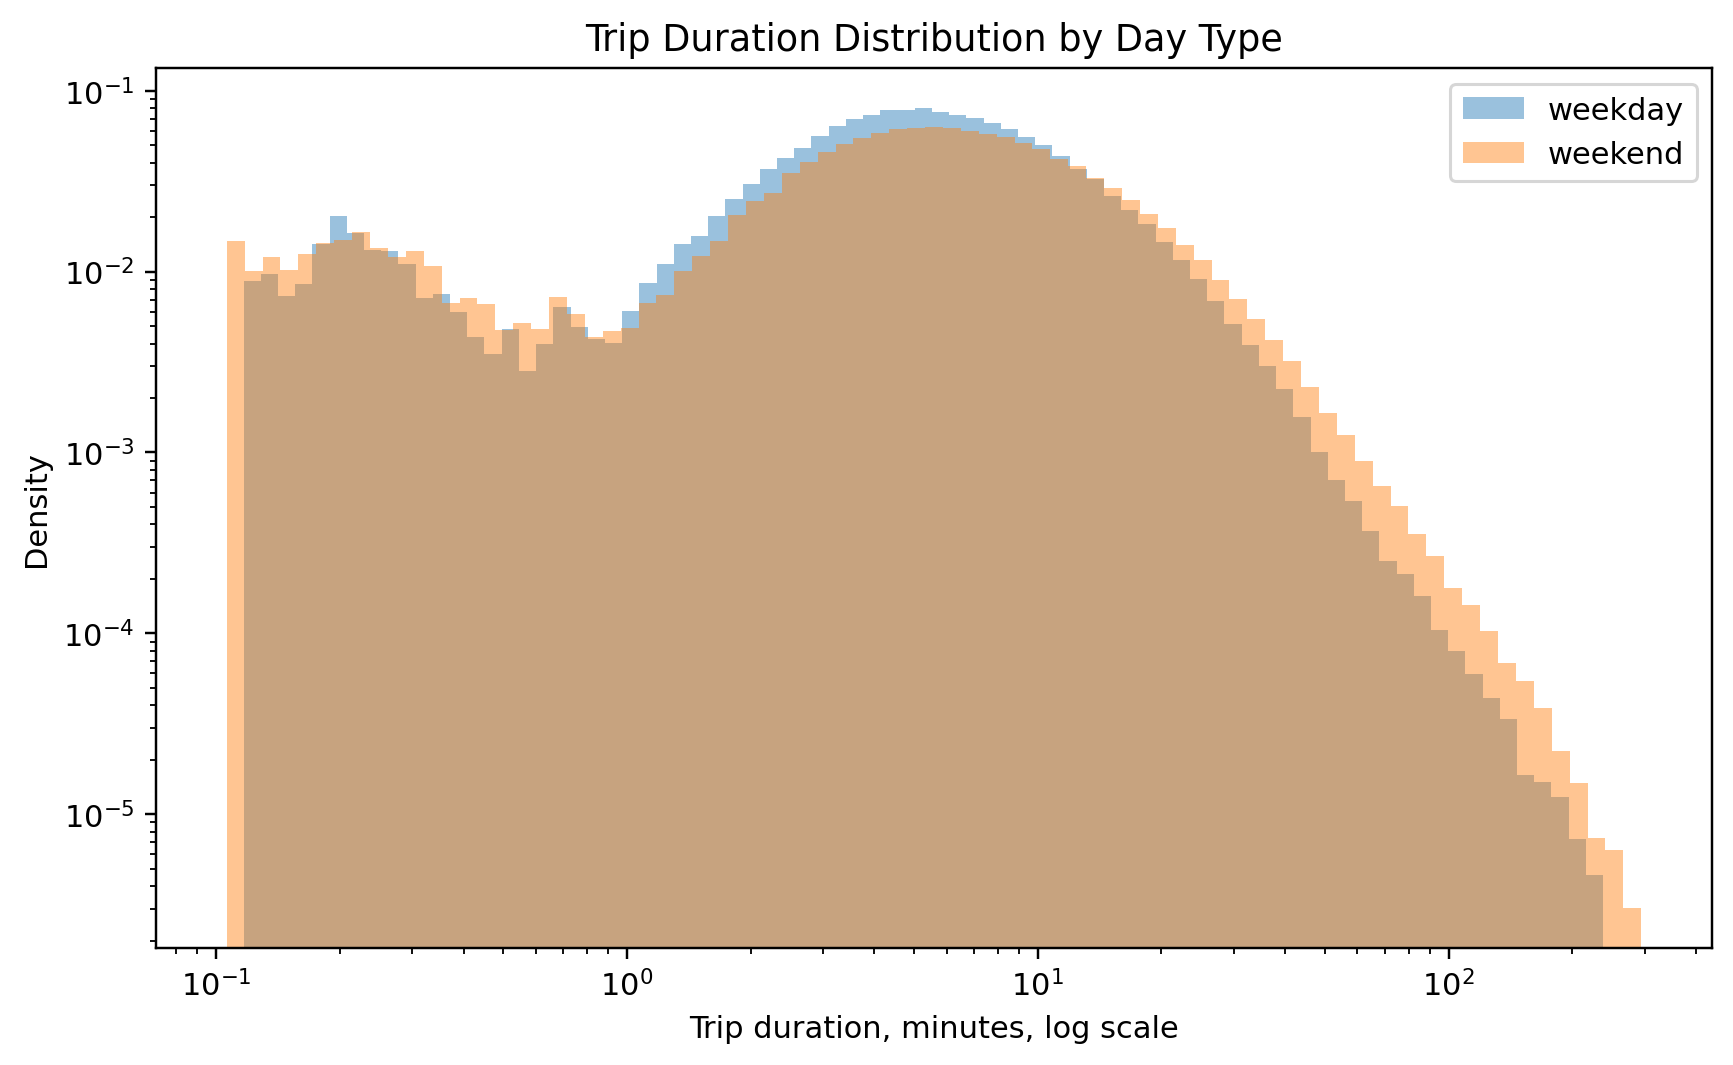

Existing figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\trip_duration_ccdf.png


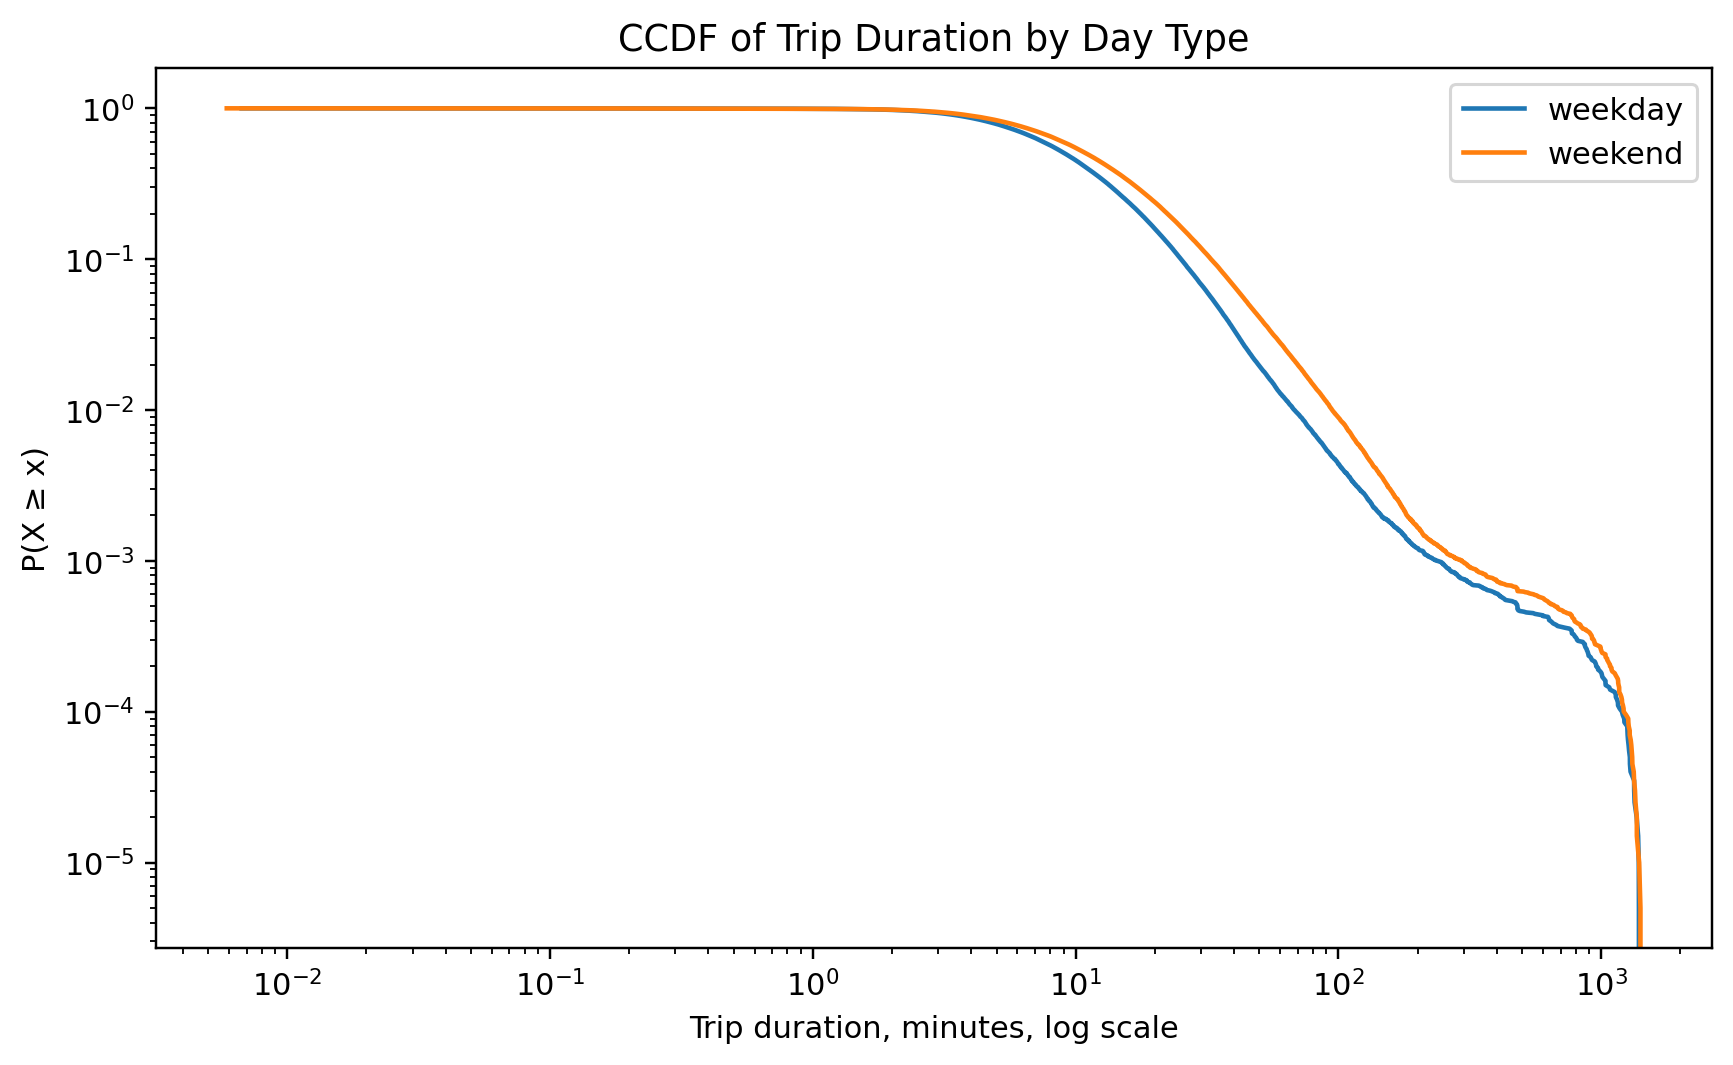

Existing figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\trip_distance_distribution_loglog.png


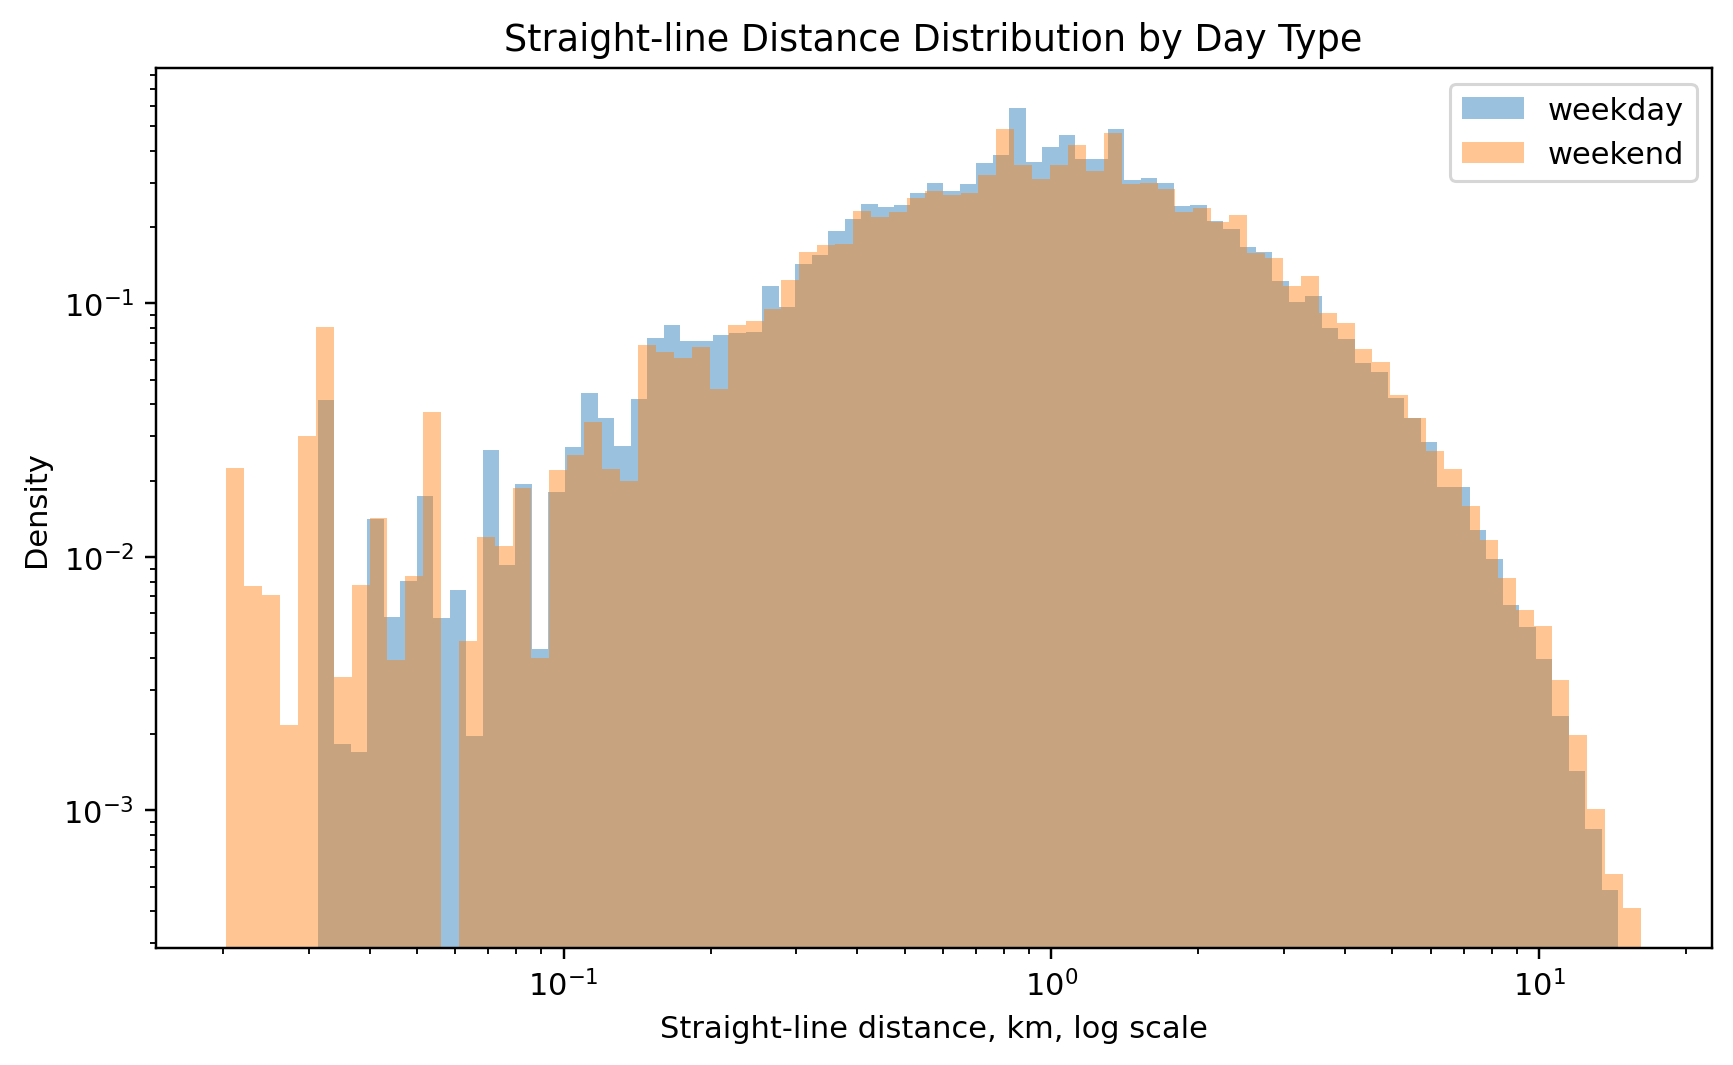

Existing figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\trip_distance_ccdf.png


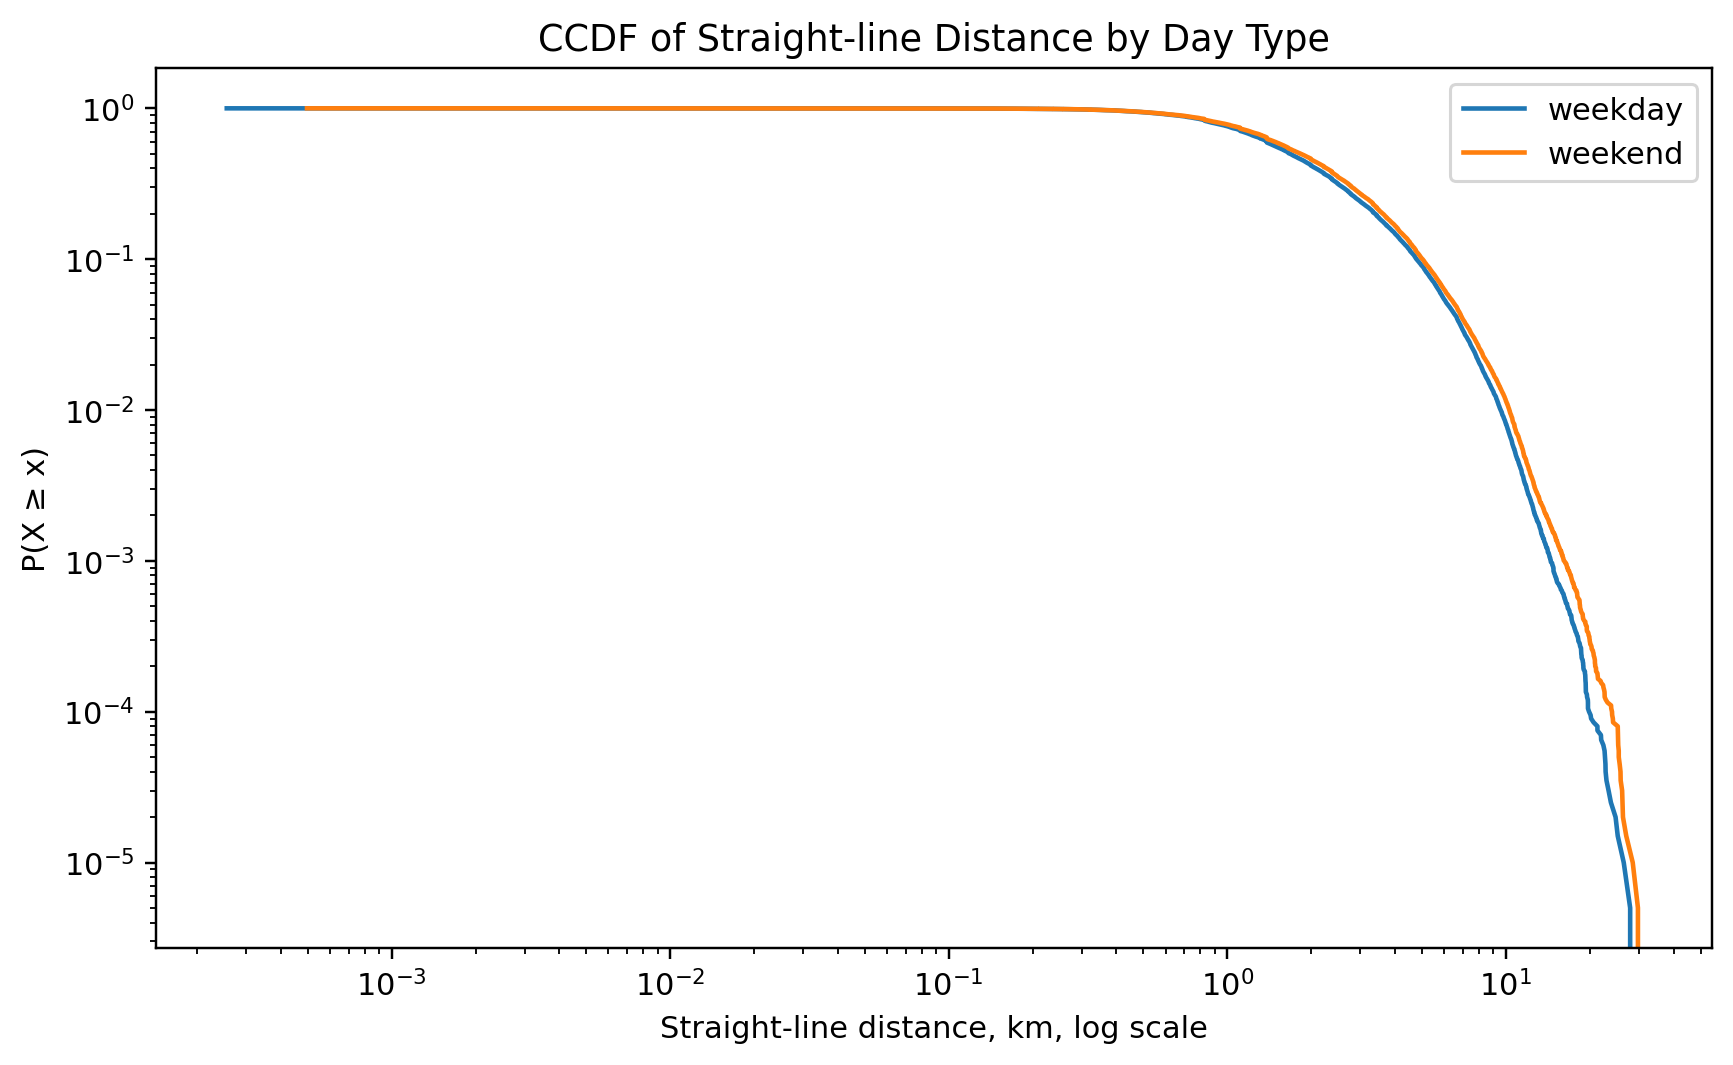

In [8]:
display(weekday_weekend_counts)
display(trip_summary)
display(distribution_fit_summary)

for figure_name in [
    "trip_duration_distribution_loglog.png",
    "trip_duration_ccdf.png",
    "trip_distance_distribution_loglog.png",
    "trip_distance_ccdf.png",
]:
    show_existing_image(figure_name)


## Baseline End Station Patterns

**Purpose.** This section tests whether high-volume weekday and weekend destinations are the same stations.

**Result to look for.** The Top 20 overlap count and station map show where weekday and weekend destination patterns diverge.

**Interpretation.** Top station counts answer **where** popular destinations differ. They do not explain **what kind of places** those destinations are, so the notebook next uses heatmaps and OSM service profiles.


Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\weekday_top20_end_stations.csv


Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\weekend_top20_end_stations.csv
Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\top20_union_end_stations.csv
Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\top20_overlap_summary.csv


,weekday_top20_count,weekend_top20_count,top20_union_count,overlap_count,overlap_percentage
0,20,20,29,11,0.5500


Saved figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\top20_union_weekday_weekend_counts.png


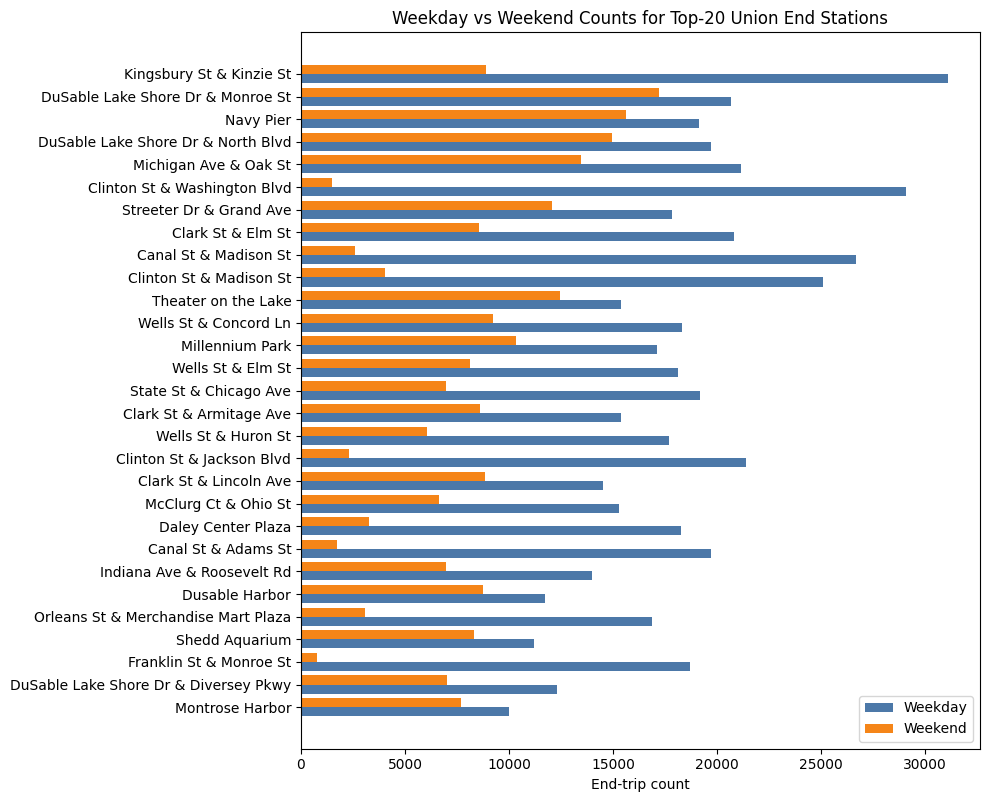

In [9]:
weekday_top20_end_stations = station_compare.sort_values("return_count_weekday", ascending=False).head(20).copy()
weekend_top20_end_stations = station_compare.sort_values("return_count_weekend", ascending=False).head(20).copy()

top20_union_end_stations = (
    pd.concat([
        weekday_top20_end_stations.assign(in_weekday_top20=True, in_weekend_top20=False),
        weekend_top20_end_stations.assign(in_weekday_top20=False, in_weekend_top20=True),
    ], ignore_index=True)
    .groupby("end_station_name", as_index=False)
    .agg(
        return_count_weekday=("return_count_weekday", "max"),
        return_count_weekend=("return_count_weekend", "max"),
        return_share_weekday=("return_share_weekday", "max"),
        return_share_weekend=("return_share_weekend", "max"),
        end_lat=("end_lat", "mean"),
        end_lng=("end_lng", "mean"),
        total_return_count=("total_return_count", "max"),
        weekend_minus_weekday_share=("weekend_minus_weekday_share", "max"),
        weekday_minus_weekend_share=("weekday_minus_weekend_share", "max"),
        orientation=("orientation", "first"),
        in_weekday_top20=("in_weekday_top20", "max"),
        in_weekend_top20=("in_weekend_top20", "max"),
    )
)
top20_union_end_stations["top20_group"] = np.select(
    [
        top20_union_end_stations["in_weekday_top20"] & top20_union_end_stations["in_weekend_top20"],
        top20_union_end_stations["in_weekday_top20"],
        top20_union_end_stations["in_weekend_top20"],
    ],
    ["overlap", "weekday_only", "weekend_only"],
    default="not_top20",
)
top20_union_end_stations["heavy_label"] = np.select(
    [
        top20_union_end_stations["weekday_minus_weekend_share"] > 0.0001,
        top20_union_end_stations["weekend_minus_weekday_share"] > 0.0001,
    ],
    ["weekday-heavy", "weekend-heavy"],
    default="mixed",
)

overlap_count = len(set(weekday_top20_end_stations["end_station_name"]) & set(weekend_top20_end_stations["end_station_name"]))
overlap_percentage = overlap_count / 20
top20_overlap_summary = pd.DataFrame([{
    "weekday_top20_count": len(weekday_top20_end_stations),
    "weekend_top20_count": len(weekend_top20_end_stations),
    "top20_union_count": len(top20_union_end_stations),
    "overlap_count": overlap_count,
    "overlap_percentage": overlap_percentage,
}])

save_table(weekday_top20_end_stations, "weekday_top20_end_stations.csv")
save_table(weekend_top20_end_stations, "weekend_top20_end_stations.csv")
save_table(top20_union_end_stations, "top20_union_end_stations.csv")
save_table(top20_overlap_summary, "top20_overlap_summary.csv")
display(top20_overlap_summary)

plot_top = top20_union_end_stations.sort_values("total_return_count", ascending=True)
y = np.arange(len(plot_top))
plt.figure(figsize=(10, max(7, len(plot_top) * 0.28)))
plt.barh(y - 0.2, plot_top["return_count_weekday"], height=0.4, label="Weekday", color="#4C78A8")
plt.barh(y + 0.2, plot_top["return_count_weekend"], height=0.4, label="Weekend", color="#F58518")
plt.yticks(y, plot_top["end_station_name"])
plt.xlabel("End-trip count")
plt.title("Weekday vs Weekend Counts for Top-20 Union End Stations")
plt.legend()
save_figure("top20_union_weekday_weekend_counts.png")
plt.show()


In [10]:
try:
    import folium
    center = [top20_union_end_stations["end_lat"].mean(), top20_union_end_stations["end_lng"].mean()]
    top20_map = folium.Map(location=center, zoom_start=12, tiles="CartoDB positron")
    colors = {"weekday_only": "blue", "weekend_only": "orange", "overlap": "purple"}
    for _, row in top20_union_end_stations.iterrows():
        group = row["top20_group"]
        popup = (
            f"<b>{row['end_station_name']}</b><br>"
            f"Group: {group}<br>"
            f"Weekday count: {int(row['return_count_weekday'])}<br>"
            f"Weekend count: {int(row['return_count_weekend'])}<br>"
            f"Label: {row['heavy_label']}"
        )
        folium.CircleMarker(
            location=[row["end_lat"], row["end_lng"]],
            radius=5 + np.log1p(row["total_return_count"]) / 2.5,
            color=colors.get(group, "gray"),
            fill=True,
            fill_opacity=0.75,
            popup=popup,
            tooltip=f"{row['end_station_name']} ({group})",
        ).add_to(top20_map)
    map_path = FINAL_OUTPUT_DIR / "top20_union_end_station_map.html"
    top20_map.save(str(map_path))
    print("Saved basemap station map:", map_path)
except Exception as exc:
    print("Skipping folium map because:", exc)


Saved basemap station map: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\top20_union_end_station_map.html


**Top 20 baseline interpretation.**

- **Purpose:** Test whether weekday and weekend high-volume end stations overlap.
- **Result:** The weekday and weekend Top 20 sets overlap by 55%, so nearly half of the high-volume destination stations differ by day type.
- **Interpretation:** This supports the need for spatial service analysis. Station counts show the locations of differences, but not the urban functions around those locations.


## Spatial Destination Heatmaps

This section tests whether weekday and weekend Divvy destination demand is spatially concentrated in different parts of Chicago.

The heatmaps are placed before the OSM service analysis because they answer **where** destination demand differs. The OSM service profiles then answer **what kinds of urban services** are near those destination areas.

Weekday trips are more numerous than weekend trips, so weekday and weekend heatmaps use normalized station shares instead of raw counts:

```text
weekday_station_share = weekday_return_count / total_weekday_returns
weekend_station_share = weekend_return_count / total_weekend_returns
```

Heatmaps are exploratory spatial evidence. They are not the main model and they are not statistical validation.


Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\station_weekday_weekend_share_difference.csv


,end_station_name,end_lat,end_lng,return_count_weekday,return_count_weekend,total_return_count,weekday_station_share,weekend_station_share,total_return_share,weekend_minus_weekday_share_normalized,weekday_minus_weekend_share_normalized,share_difference_orientation
297,DuSable Lake Shore Dr & Monroe St,41.8810,-87.6167,"20,698.0000","17,218.0000","37,916.0000",0.0067,0.0143,0.0088,0.0076,-0.0076,weekend_oriented
715,Navy Pier,41.8923,-87.6120,"19,160.0000","15,617.0000","34,777.0000",0.0062,0.0130,0.0081,0.0068,-0.0068,weekend_oriented
298,DuSable Lake Shore Dr & North Blvd,41.9117,-87.6268,"19,730.0000","14,940.0000","34,670.0000",0.0064,0.0124,0.0081,0.0060,-0.0060,weekend_oriented
1014,Theater on the Lake,41.9263,-87.6308,"15,407.0000","12,444.0000","27,851.0000",0.0050,0.0103,0.0065,0.0054,-0.0054,weekend_oriented
666,Michigan Ave & Oak St,41.9010,-87.6238,"21,157.0000","13,471.0000","34,628.0000",0.0068,0.0112,0.0081,0.0043,-0.0043,weekend_oriented
1010,Streeter Dr & Grand Ave,41.8923,-87.6120,"17,854.0000","12,071.0000","29,925.0000",0.0058,0.0100,0.0070,0.0043,-0.0043,weekend_oriented
301,Dusable Harbor,41.8870,-87.6128,"11,732.0000","8,761.0000","20,493.0000",0.0038,0.0073,0.0048,0.0035,-0.0035,weekend_oriented
921,Shedd Aquarium,41.8672,-87.6154,"11,191.0000","8,315.0000","19,506.0000",0.0036,0.0069,0.0045,0.0033,-0.0033,weekend_oriented
690,Montrose Harbor,41.9640,-87.6382,"10,026.0000","7,717.0000","17,743.0000",0.0032,0.0064,0.0041,0.0032,-0.0032,weekend_oriented
673,Millennium Park,41.8810,-87.6241,"17,129.0000","10,356.0000","27,485.0000",0.0055,0.0086,0.0064,0.0031,-0.0031,weekend_oriented


Saved heatmap: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\all_returns_destination_heatmap.html


Saved heatmap: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\weekday_destination_heatmap.html
Saved heatmap: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\weekend_destination_heatmap.html


Saved difference map: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\weekend_minus_weekday_destination_difference_map.html


Saved figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\all_returns_destination_heatmap.png


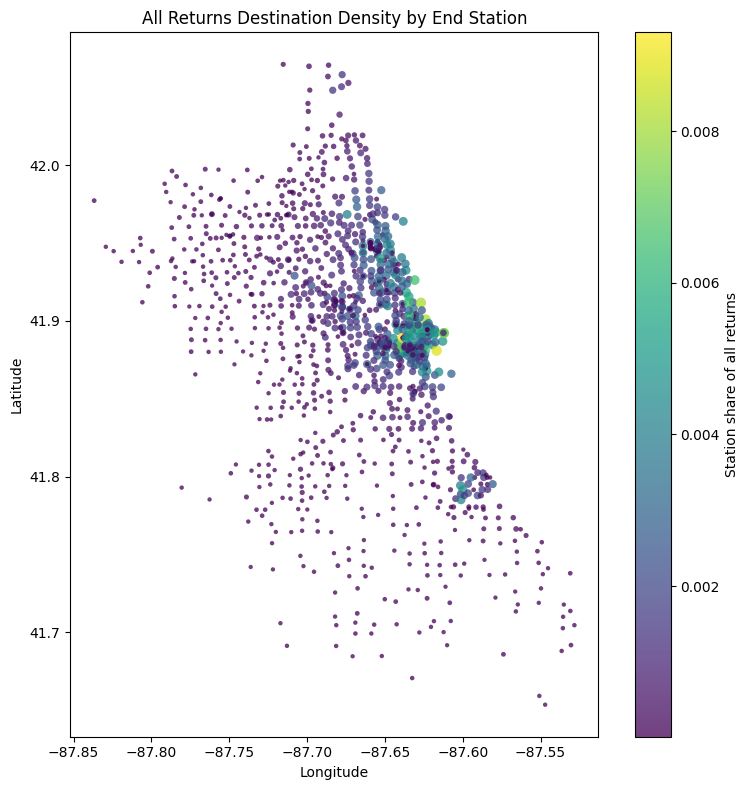

Saved figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\weekday_weekend_normalized_destination_heatmaps.png


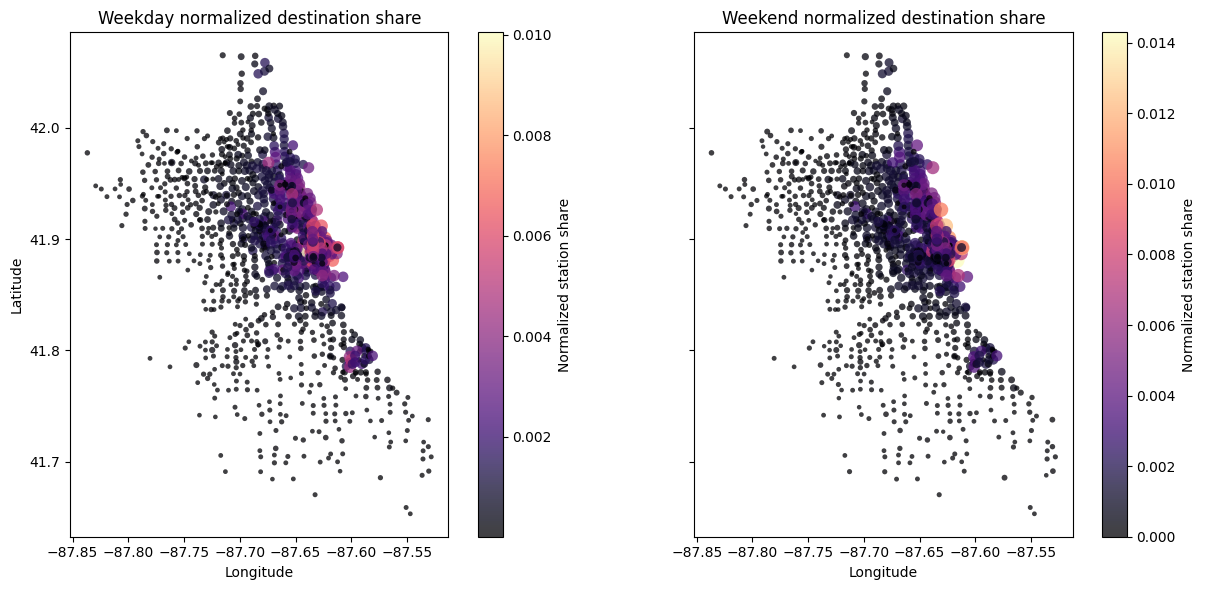

Saved figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\weekend_minus_weekday_destination_difference_map.png


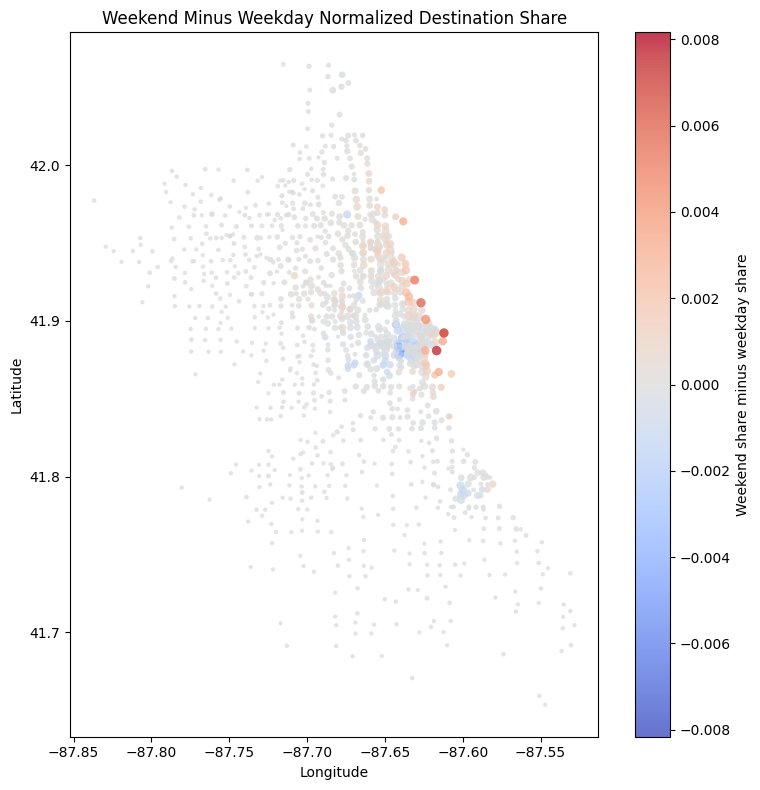

Heatmap interpretation: all-return density gives spatial context; normalized weekday/weekend heatmaps compare destination shares fairly; the difference map identifies weekend-oriented and weekday-oriented stations. These maps motivate the OSM service-profile analysis.


In [11]:
try:
    import folium
    from folium.plugins import HeatMap
except Exception as exc:
    folium = None
    HeatMap = None
    print("Skipping interactive heatmaps because folium is unavailable:", exc)

heatmap_df = station_compare.dropna(subset=["end_lat", "end_lng"]).copy()
heatmap_df = heatmap_df[
    heatmap_df["end_lat"].between(*CHICAGO_LAT_RANGE)
    & heatmap_df["end_lng"].between(*CHICAGO_LNG_RANGE)
].copy()

total_weekday_returns = heatmap_df["return_count_weekday"].sum()
total_weekend_returns = heatmap_df["return_count_weekend"].sum()
total_returns = heatmap_df["total_return_count"].sum()

heatmap_df["weekday_station_share"] = heatmap_df["return_count_weekday"] / total_weekday_returns
heatmap_df["weekend_station_share"] = heatmap_df["return_count_weekend"] / total_weekend_returns
heatmap_df["total_return_share"] = heatmap_df["total_return_count"] / total_returns
heatmap_df["weekend_minus_weekday_share_normalized"] = (
    heatmap_df["weekend_station_share"] - heatmap_df["weekday_station_share"]
)
heatmap_df["weekday_minus_weekend_share_normalized"] = -heatmap_df["weekend_minus_weekday_share_normalized"]
heatmap_df["share_difference_orientation"] = np.select(
    [
        heatmap_df["weekend_minus_weekday_share_normalized"] > 0,
        heatmap_df["weekend_minus_weekday_share_normalized"] < 0,
    ],
    ["weekend_oriented", "weekday_oriented"],
    default="balanced",
)

station_share_difference = heatmap_df[
    [
        "end_station_name", "end_lat", "end_lng",
        "return_count_weekday", "return_count_weekend", "total_return_count",
        "weekday_station_share", "weekend_station_share", "total_return_share",
        "weekend_minus_weekday_share_normalized",
        "weekday_minus_weekend_share_normalized",
        "share_difference_orientation",
    ]
].sort_values("weekend_minus_weekday_share_normalized", ascending=False)
save_table(station_share_difference, "station_weekday_weekend_share_difference.csv")

display(station_share_difference.head(10))


def scaled_heatmap_points(df, weight_col, scale=1_000_000):
    return (
        df[["end_lat", "end_lng", weight_col]]
        .dropna()
        .assign(weight=lambda frame: frame[weight_col] * scale)
        [["end_lat", "end_lng", "weight"]]
        .values
        .tolist()
    )


def save_heatmap_html(df, weight_col, filename, title):
    if folium is None or HeatMap is None:
        return None
    center = [df["end_lat"].mean(), df["end_lng"].mean()]
    fmap = folium.Map(location=center, zoom_start=11, tiles="CartoDB positron")
    HeatMap(
        scaled_heatmap_points(df, weight_col),
        radius=15,
        blur=18,
        min_opacity=0.25,
        name=title,
    ).add_to(fmap)
    folium.LayerControl().add_to(fmap)
    html_path = FINAL_FIGURE_DIR / filename
    fmap.save(str(html_path))
    print("Saved heatmap:", html_path)
    return html_path


if folium is not None:
    save_heatmap_html(heatmap_df, "total_return_share", "all_returns_destination_heatmap.html", "All returns")
    save_heatmap_html(heatmap_df, "weekday_station_share", "weekday_destination_heatmap.html", "Weekday normalized")
    save_heatmap_html(heatmap_df, "weekend_station_share", "weekend_destination_heatmap.html", "Weekend normalized")

    diff_center = [heatmap_df["end_lat"].mean(), heatmap_df["end_lng"].mean()]
    diff_map = folium.Map(location=diff_center, zoom_start=11, tiles="CartoDB positron")
    diff_plot = station_share_difference.copy()
    max_abs_diff = diff_plot["weekend_minus_weekday_share_normalized"].abs().max()
    for _, row in diff_plot.iterrows():
        diff_value = row["weekend_minus_weekday_share_normalized"]
        color = "#F58518" if diff_value > 0 else "#4C78A8"
        radius = 3 + 12 * (abs(diff_value) / max_abs_diff if max_abs_diff else 0)
        popup = (
            f"<b>{row['end_station_name']}</b><br>"
            f"Orientation: {row['share_difference_orientation']}<br>"
            f"Weekday share: {row['weekday_station_share']:.5f}<br>"
            f"Weekend share: {row['weekend_station_share']:.5f}<br>"
            f"Weekend - weekday share: {diff_value:.5f}<br>"
            f"Weekday count: {int(row['return_count_weekday'])}<br>"
            f"Weekend count: {int(row['return_count_weekend'])}"
        )
        folium.CircleMarker(
            location=[row["end_lat"], row["end_lng"]],
            radius=radius,
            color=color,
            fill=True,
            fill_opacity=0.65,
            weight=1,
            popup=popup,
            tooltip=f"{row['end_station_name']}: {diff_value:.5f}",
        ).add_to(diff_map)
    legend_html = '''
    <div style="position: fixed; bottom: 35px; left: 35px; z-index: 9999;
                background: white; padding: 10px 12px; border: 1px solid #999;
                font-size: 13px;">
      <b>Weekend minus weekday station share</b><br>
      <span style="color:#F58518;">●</span> Weekend-oriented<br>
      <span style="color:#4C78A8;">●</span> Weekday-oriented
    </div>
    '''
    diff_map.get_root().html.add_child(folium.Element(legend_html))
    diff_map_path = FINAL_FIGURE_DIR / "weekend_minus_weekday_destination_difference_map.html"
    diff_map.save(str(diff_map_path))
    print("Saved difference map:", diff_map_path)


def save_static_station_density(df):
    fig, ax = plt.subplots(figsize=(8, 8))
    sizes = 8 + np.sqrt(df["total_return_count"].clip(lower=0)) / 4
    sc = ax.scatter(
        df["end_lng"], df["end_lat"],
        s=sizes,
        c=df["total_return_share"],
        cmap="viridis",
        alpha=0.75,
        linewidth=0,
    )
    ax.set_title("All Returns Destination Density by End Station")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal", adjustable="box")
    fig.colorbar(sc, ax=ax, label="Station share of all returns")
    save_figure("all_returns_destination_heatmap.png")
    plt.show()


def save_static_weekday_weekend(df):
    fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)
    for ax, col, title in [
        (axes[0], "weekday_station_share", "Weekday normalized destination share"),
        (axes[1], "weekend_station_share", "Weekend normalized destination share"),
    ]:
        sizes = 8 + np.sqrt(df[col].clip(lower=0) * 1_000_000)
        sc = ax.scatter(
            df["end_lng"], df["end_lat"],
            s=sizes,
            c=df[col],
            cmap="magma",
            alpha=0.75,
            linewidth=0,
        )
        ax.set_title(title)
        ax.set_xlabel("Longitude")
        ax.set_aspect("equal", adjustable="box")
        fig.colorbar(sc, ax=ax, label="Normalized station share")
    axes[0].set_ylabel("Latitude")
    save_figure("weekday_weekend_normalized_destination_heatmaps.png")
    plt.show()


def save_static_difference(df):
    plot_df = df.sort_values("weekend_minus_weekday_share_normalized")
    fig, ax = plt.subplots(figsize=(8, 8))
    max_abs = plot_df["weekend_minus_weekday_share_normalized"].abs().max()
    sc = ax.scatter(
        plot_df["end_lng"], plot_df["end_lat"],
        s=8 + np.sqrt(plot_df["total_return_count"].clip(lower=0)) / 5,
        c=plot_df["weekend_minus_weekday_share_normalized"],
        cmap="coolwarm",
        vmin=-max_abs,
        vmax=max_abs,
        alpha=0.78,
        linewidth=0,
    )
    ax.set_title("Weekend Minus Weekday Normalized Destination Share")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal", adjustable="box")
    fig.colorbar(sc, ax=ax, label="Weekend share minus weekday share")
    save_figure("weekend_minus_weekday_destination_difference_map.png")
    plt.show()


save_static_station_density(heatmap_df)
save_static_weekday_weekend(heatmap_df)
save_static_difference(heatmap_df)

print(
    "Heatmap interpretation: all-return density gives spatial context; normalized weekday/weekend heatmaps compare destination shares fairly; "
    "the difference map identifies weekend-oriented and weekday-oriented stations. These maps motivate the OSM service-profile analysis."
)


**Heatmap interpretation.**

- The all-return destination heatmap provides spatial context by showing where Divvy returns are concentrated overall.
- The weekday and weekend normalized heatmaps compare station shares rather than raw counts, so the comparison is not dominated by the larger number of weekday trips.
- The weekend-minus-weekday difference map identifies relatively weekend-oriented and weekday-oriented stations. Lakefront and tourism destinations appear more weekend-oriented, while downtown commute stations appear more weekday-oriented.

These maps provide exploratory spatial evidence that destination demand differs by day type. They do not explain rider intent and they do not validate the service-profile model by themselves. They motivate the next step: using OSM service profiles to describe what kinds of urban service environments are near those destination areas.


## OSM Service Analysis for Top End Stations

The Top 20 union is the bridge from the baseline result to the service-environment analysis. The previous cached OSM tables only covered part of the Top 20 union, so this notebook refreshes OSM service counts from the local citywide POI cache using station coordinates.

This avoids using station name as the only matching key. Each station is matched to nearby OSM POIs by latitude/longitude and search radius.

`other_amenity` is kept in the raw service-count outputs as a catch-all context category, but it is excluded from the main interpreted profiles because it mixes many unrelated amenities and is hard to defend as a behavioral category.


Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\service_category_definitions.csv


,service_category,included_osm_tags,main_analysis_use
0,education,"amenity=school, university, college, library",Interpretable category
1,food_drink,"amenity=restaurant, cafe, bar, pub, fast_food",Interpretable category
2,health,"amenity=hospital, clinic, doctors, dentist, ph...",Interpretable category
3,office,office=*,Interpretable category
4,recreation,"leisure=park, garden, fitness_centre, sports_c...",Interpretable category
5,retail,shop=*,Interpretable category
6,tourism,tourism=*,Interpretable category
7,transit,"public_transport=*, railway=station/stop/subwa...",Interpretable category
8,other_amenity,"catch-all category, for example parking, bench...",Kept in raw counts only; excluded from interpr...


Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\refreshed_osm_service_counts_top20_union_100m.csv


Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\refreshed_osm_service_counts_top20_union_250m.csv
Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\refreshed_osm_services_top20_union_250m.csv


Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\refreshed_osm_service_counts_top20_union_500m.csv


...

Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\refreshed_osm_service_counts_top100_union_100m.csv


Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\refreshed_osm_service_counts_top100_union_250m.csv
Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\refreshed_osm_services_top100_union_250m.csv
Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\refreshed_osm_service_counts_top100_union_500m.csv
Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\top20_union_osm_services.csv
Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\top20_station_service_profiles.csv
Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\top20_union_osm_coverage.csv


,top20_union_count,covered_by_coordinate_osm_count,missing_coordinate_osm_count,covered_return_count,top20_union_return_count,covered_top20_union_return_share,missing_coordinate_osm_stations,osm_radius_m,other_amenity_policy
0,29,24,5,"650,531.0000","762,892.0000",0.8527,Clark St & Armitage Ave; Clark St & Lincoln Av...,250,excluded from interpreted profiles; retained i...


Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\top20_heavy_label_service_profiles.csv


Saved figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\top20_heavy_label_service_comparison.png


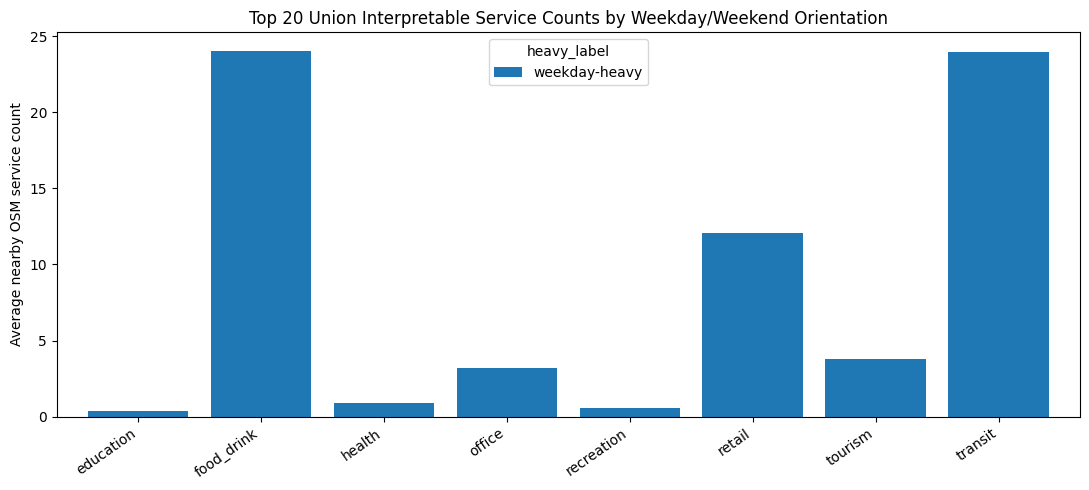

In [12]:
OSM_POI_CACHE_PATH = first_existing_path("osm_pois_chicago_services.csv", OUTPUT_DIR, DATA_OUTPUT_DIR)
osm_pois = pd.read_csv(OSM_POI_CACHE_PATH).dropna(subset=["lat", "lon", "service_category"]).copy()
osm_pois["service_category"] = osm_pois["service_category"].replace({"other_service": "other_amenity"})

ALL_SERVICE_CATEGORIES = [
    "education", "food_drink", "health", "office", "other_amenity",
    "recreation", "retail", "tourism", "transit",
]
INTERPRETABLE_SERVICE_CATEGORIES = [
    "education", "food_drink", "health", "office",
    "recreation", "retail", "tourism", "transit",
]

service_category_definitions = pd.DataFrame([
    {
        "service_category": "education",
        "included_osm_tags": "amenity=school, university, college, library",
        "main_analysis_use": "Interpretable category",
    },
    {
        "service_category": "food_drink",
        "included_osm_tags": "amenity=restaurant, cafe, bar, pub, fast_food",
        "main_analysis_use": "Interpretable category",
    },
    {
        "service_category": "health",
        "included_osm_tags": "amenity=hospital, clinic, doctors, dentist, pharmacy",
        "main_analysis_use": "Interpretable category",
    },
    {
        "service_category": "office",
        "included_osm_tags": "office=*",
        "main_analysis_use": "Interpretable category",
    },
    {
        "service_category": "recreation",
        "included_osm_tags": "leisure=park, garden, fitness_centre, sports_centre, marina, stadium, pitch, playground",
        "main_analysis_use": "Interpretable category",
    },
    {
        "service_category": "retail",
        "included_osm_tags": "shop=*",
        "main_analysis_use": "Interpretable category",
    },
    {
        "service_category": "tourism",
        "included_osm_tags": "tourism=*",
        "main_analysis_use": "Interpretable category",
    },
    {
        "service_category": "transit",
        "included_osm_tags": "public_transport=*, railway=station/stop/subway_entrance, highway=bus_stop, amenity=bus_station",
        "main_analysis_use": "Interpretable category",
    },
    {
        "service_category": "other_amenity",
        "included_osm_tags": "catch-all category, for example parking, bench, waste_basket, post_box, toilets, bank, vending_machine",
        "main_analysis_use": "Kept in raw counts only; excluded from interpreted profiles and validation",
    },
])
save_table(service_category_definitions, "service_category_definitions.csv")
display(service_category_definitions)

EARTH_RADIUS_METERS = 6_371_008.8
poi_lat_rad = np.radians(osm_pois["lat"].astype(float).to_numpy())
poi_lon_rad = np.radians(osm_pois["lon"].astype(float).to_numpy())


def haversine_distances_m(lat, lon):
    lat_rad = np.radians(float(lat))
    lon_rad = np.radians(float(lon))
    dlat = poi_lat_rad - lat_rad
    dlon = poi_lon_rad - lon_rad
    a = np.sin(dlat / 2) ** 2 + np.cos(lat_rad) * np.cos(poi_lat_rad) * np.sin(dlon / 2) ** 2
    return 2 * EARTH_RADIUS_METERS * np.arcsin(np.sqrt(a))


def build_topk_union(station_df, k):
    weekday_names = set(station_df.nlargest(k, "return_count_weekday")["end_station_name"])
    weekend_names = set(station_df.nlargest(k, "return_count_weekend")["end_station_name"])
    topk = station_df[station_df["end_station_name"].isin(weekday_names | weekend_names)].copy()
    topk["topk_union"] = k
    topk["topk_group"] = np.select(
        [
            topk["end_station_name"].isin(weekday_names & weekend_names),
            topk["end_station_name"].isin(weekday_names),
            topk["end_station_name"].isin(weekend_names),
        ],
        ["overlap", "weekday_only", "weekend_only"],
        default="outside_topk",
    )
    topk["heavy_label"] = np.select(
        [
            topk["return_count_weekday"] > topk["return_count_weekend"],
            topk["return_count_weekend"] > topk["return_count_weekday"],
        ],
        ["weekday-heavy", "weekend-heavy"],
        default="mixed",
    )
    return topk


def compute_station_service_counts(stations, radius_m, include_detail=False):
    count_rows = []
    detail_rows = []
    for _, station in stations.iterrows():
        distances_m = haversine_distances_m(station["end_lat"], station["end_lng"])
        nearby = osm_pois.loc[distances_m <= radius_m].copy()
        nearby["distance_m"] = distances_m[distances_m <= radius_m]
        category_counts = nearby["service_category"].value_counts()

        row = {
            "end_station_name": station["end_station_name"],
            "end_lat": station["end_lat"],
            "end_lng": station["end_lng"],
            "return_count_weekday": station["return_count_weekday"],
            "return_count_weekend": station["return_count_weekend"],
            "total_return_count": station["total_return_count"],
            "heavy_label": station.get("heavy_label", ""),
            "topk_group": station.get("topk_group", ""),
            "topk_union": station.get("topk_union", np.nan),
            "search_radius_m": radius_m,
        }
        for category in ALL_SERVICE_CATEGORIES:
            row[category] = int(category_counts.get(category, 0))
        row["total_services_all"] = int(sum(row[category] for category in ALL_SERVICE_CATEGORIES))
        row["total_services_interpretable"] = int(sum(row[category] for category in INTERPRETABLE_SERVICE_CATEGORIES))
        count_rows.append(row)

        if include_detail and not nearby.empty:
            for _, poi in nearby.iterrows():
                detail_rows.append({
                    "end_station_name": station["end_station_name"],
                    "station_end_trip_count": station["total_return_count"],
                    "station_lat": station["end_lat"],
                    "station_lng": station["end_lng"],
                    "search_radius_m": radius_m,
                    "distance_m": poi["distance_m"],
                    "service_category": poi["service_category"],
                    "service_lat": poi["lat"],
                    "service_lng": poi["lon"],
                    "name": poi.get("name", ""),
                    "amenity": poi.get("amenity", ""),
                    "shop": poi.get("shop", ""),
                    "tourism": poi.get("tourism", ""),
                    "office": poi.get("office", ""),
                    "leisure": poi.get("leisure", ""),
                    "public_transport": poi.get("public_transport", ""),
                    "railway": poi.get("railway", ""),
                    "highway": poi.get("highway", ""),
                })

    return pd.DataFrame(count_rows), pd.DataFrame(detail_rows)


topk_union_sets = {k: build_topk_union(station_compare, k) for k in TOPK_LIST}
top20_union_for_osm = topk_union_sets[20].copy()
main_profile_stations = topk_union_sets[MAIN_PROFILE_TOP_K].copy()

osm_service_counts_by_topk_radius = {}
osm_service_details_by_topk_radius = {}
for k, topk_stations in topk_union_sets.items():
    for radius in RADIUS_LIST:
        counts, details = compute_station_service_counts(
            topk_stations,
            radius,
            include_detail=(radius == OSM_RADIUS_MAIN),
        )
        osm_service_counts_by_topk_radius[(k, radius)] = counts
        osm_service_details_by_topk_radius[(k, radius)] = details
        save_table(counts, f"refreshed_osm_service_counts_top{k}_union_{radius}m.csv")
        if radius == OSM_RADIUS_MAIN:
            save_table(details, f"refreshed_osm_services_top{k}_union_{radius}m.csv")

top20_union_osm_services = osm_service_details_by_topk_radius[(20, OSM_RADIUS_MAIN)].copy()
top20_station_service_profiles = osm_service_counts_by_topk_radius[(20, OSM_RADIUS_MAIN)].copy()
top20_station_service_profiles = top20_station_service_profiles.rename(columns={"topk_group": "top20_group"})

covered_top20 = set(top20_station_service_profiles.loc[
    top20_station_service_profiles["total_services_interpretable"] > 0,
    "end_station_name",
])
top20_names = set(top20_union_end_stations["end_station_name"])
missing_top20_osm = sorted(top20_names - covered_top20)
top20_osm_coverage = pd.DataFrame([{
    "top20_union_count": len(top20_names),
    "covered_by_coordinate_osm_count": len(covered_top20),
    "missing_coordinate_osm_count": len(missing_top20_osm),
    "covered_return_count": top20_station_service_profiles.loc[
        top20_station_service_profiles["total_services_interpretable"] > 0,
        "total_return_count",
    ].sum(),
    "top20_union_return_count": top20_station_service_profiles["total_return_count"].sum(),
    "covered_top20_union_return_share": top20_station_service_profiles.loc[
        top20_station_service_profiles["total_services_interpretable"] > 0,
        "total_return_count",
    ].sum() / top20_station_service_profiles["total_return_count"].sum(),
    "missing_coordinate_osm_stations": "; ".join(missing_top20_osm),
    "osm_radius_m": OSM_RADIUS_MAIN,
    "other_amenity_policy": "excluded from interpreted profiles; retained in raw counts",
}])

save_table(top20_union_osm_services, "top20_union_osm_services.csv")
save_table(top20_station_service_profiles, "top20_station_service_profiles.csv")
save_table(top20_osm_coverage, "top20_union_osm_coverage.csv")
display(top20_osm_coverage)

service_cols_for_top20 = INTERPRETABLE_SERVICE_CATEGORIES
top20_profile_covered = top20_station_service_profiles[
    top20_station_service_profiles["total_services_interpretable"] > 0
].copy()
group_profiles = (
    top20_profile_covered.groupby("heavy_label")[service_cols_for_top20]
    .mean()
    .reset_index()
)
save_table(group_profiles, "top20_heavy_label_service_profiles.csv")

group_plot = group_profiles.set_index("heavy_label").T
group_plot.plot(kind="bar", figsize=(11, 5), width=0.82)
plt.ylabel("Average nearby OSM service count")
plt.title("Top 20 Union Interpretable Service Counts by Weekday/Weekend Orientation")
plt.xticks(rotation=35, ha="right")
save_figure("top20_heavy_label_service_comparison.png")
plt.show()


## Destination-Service Profiling Framework

This is the main analytical framework. It is not an AI prediction model.

1. Treat each end station as a destination proxy.
2. Convert each station into an OSM service vector using nearby services within `OSM_RADIUS_MAIN` meters.
3. Exclude `other_amenity` from the interpreted profile because it is a heterogeneous catch-all category.
4. Normalize each station's interpretable service vector so dense downtown stations do not dominate only because they have more mapped POIs.
5. Compute weighted weekday and weekend profiles using end-trip counts as weights.
6. Compare profiles to identify weekday-oriented and weekend-oriented urban service environments.

**Method formula.**

For station `i`, define a normalized service vector:

```text
S_i = [education_i, food_drink_i, health_i, office_i, recreation_i, retail_i, tourism_i, transit_i]
```

Define return-count weights:

```text
w_i,weekday = weekday_return_count_i / sum(weekday_return_count)
w_i,weekend = weekend_return_count_i / sum(weekend_return_count)
```

Weighted service profiles:

```text
P_weekday = sum_i w_i,weekday * S_i
P_weekend = sum_i w_i,weekend * S_i
```

Difference vector:

```text
D = P_weekend - P_weekday
```

Positive values in `D` are weekend-oriented services. Negative values are weekday-oriented services.

Top 20 stations are used for a clear baseline map and case-study table. The main service-profile results use the Top 100 weekday/weekend union when OSM coverage is available, which gives a more stable analysis set.


In [13]:
SERVICE_EXCLUDE_COLUMNS = {
    "end_station_name", "end_trip_count", "station_end_trip_count", "end_lat", "end_lng",
    "station_lat", "station_lng", "search_radius_m", "matched_address", "heavy_label",
    "topk_group", "top20_group", "topk_union", "total_return_count", "return_count_weekday",
    "return_count_weekend", "total_services_all", "total_services_interpretable",
}


def identify_service_columns(service_df, interpretable_only=True):
    preferred = INTERPRETABLE_SERVICE_CATEGORIES if interpretable_only else ALL_SERVICE_CATEGORIES
    return [col for col in preferred if col in service_df.columns and pd.api.types.is_numeric_dtype(service_df[col])]


def build_station_service_vector(service_df, interpretable_only=True):
    service = service_df.copy()
    service["end_station_name"] = service["end_station_name"].astype(str).str.strip()
    service_cols = identify_service_columns(service, interpretable_only=interpretable_only)
    vectors = service.set_index("end_station_name")[service_cols].fillna(0).astype(float)
    return vectors, service_cols


def normalize_service_vectors(service_vectors):
    row_sum = service_vectors.sum(axis=1)
    return service_vectors.div(row_sum.replace(0, np.nan), axis=0).fillna(0)


def prepare_profile_dataset(station_df, service_df, interpretable_only=True):
    station = station_df.copy()
    service = service_df.copy()
    station["end_station_name"] = station["end_station_name"].astype(str).str.strip()
    service["end_station_name"] = service["end_station_name"].astype(str).str.strip()
    merged = station.merge(service, on="end_station_name", how="inner", suffixes=("", "_service"))
    service_cols = identify_service_columns(service, interpretable_only=interpretable_only)
    if not service_cols:
        raise ValueError("No service columns were found in the OSM service table.")
    coverage_col = "total_services_interpretable" if interpretable_only else "total_services_all"
    if coverage_col in merged.columns:
        merged = merged[merged[coverage_col] > 0].copy()
    return merged, service_cols


def compute_weighted_service_profile(df, service_cols, weight_col):
    vectors = df.set_index("end_station_name")[service_cols].fillna(0).astype(float)
    matrix = normalize_service_vectors(vectors)
    weights = pd.to_numeric(df[weight_col], errors="coerce").fillna(0).astype(float)
    if weights.sum() == 0:
        return pd.Series(np.zeros(len(service_cols)), index=service_cols)
    weights = weights / weights.sum()
    return pd.Series(matrix.to_numpy().T.dot(weights.to_numpy()), index=service_cols)


def compute_profile_difference(weekday_profile, weekend_profile):
    table = pd.DataFrame({
        "service_category": weekday_profile.index,
        "weekday_profile": weekday_profile.values,
        "weekend_profile": weekend_profile.reindex(weekday_profile.index).values,
    })
    table["weekend_minus_weekday"] = table["weekend_profile"] - table["weekday_profile"]
    table["weekday_minus_weekend"] = -table["weekend_minus_weekday"]
    return table.sort_values("weekend_minus_weekday", ascending=False).reset_index(drop=True)


weighted_service_profile = compute_weighted_service_profile
profile_comparison_table = compute_profile_difference

service_counts_all_radii = {
    radius: osm_service_counts_by_topk_radius[(MAIN_PROFILE_TOP_K, radius)].copy()
    for radius in RADIUS_LIST
}
service_counts_250 = service_counts_all_radii[OSM_RADIUS_MAIN].copy()

station_service_vectors_250, service_cols_250 = build_station_service_vector(service_counts_250, interpretable_only=True)
normalized_station_service_vectors_250 = normalize_service_vectors(station_service_vectors_250)
profile_df_250, service_cols_250 = prepare_profile_dataset(main_profile_stations, service_counts_250, interpretable_only=True)

coverage_rows = []
for k in TOPK_LIST:
    counts_k = osm_service_counts_by_topk_radius[(k, OSM_RADIUS_MAIN)].copy()
    covered_k = counts_k[counts_k["total_services_interpretable"] > 0].copy()
    coverage_rows.append({
        "analysis_set": f"top{k}_weekday_weekend_union",
        "topk_union": k,
        "union_station_count": len(counts_k),
        "stations_with_interpretable_osm_profile": len(covered_k),
        "station_coverage_share": len(covered_k) / len(counts_k),
        "covered_return_count": covered_k["total_return_count"].sum(),
        "union_return_count": counts_k["total_return_count"].sum(),
        "covered_return_share": covered_k["total_return_count"].sum() / counts_k["total_return_count"].sum(),
        "osm_radius_m": OSM_RADIUS_MAIN,
        "other_amenity_policy": "excluded from interpreted profiles; retained in raw counts",
    })
coverage = pd.DataFrame(coverage_rows)
save_table(coverage, "osm_profile_coverage.csv")
display(coverage)


Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\osm_profile_coverage.csv


,analysis_set,topk_union,union_station_count,stations_with_interpretable_osm_profile,station_coverage_share,covered_return_count,union_return_count,covered_return_share,osm_radius_m,other_amenity_policy
0,top20_weekday_weekend_union,20,29,24,0.8276,"650,531.0000","762,892.0000",0.8527,250,excluded from interpreted profiles; retained i...
1,top50_weekday_weekend_union,50,72,45,0.6250,"1,045,023.0000","1,524,188.0000",0.6856,250,excluded from interpreted profiles; retained i...
2,top100_weekday_weekend_union,100,129,75,0.5814,"1,436,667.0000","2,257,954.0000",0.6363,250,excluded from interpreted profiles; retained i...


## Main OSM Service Profile Results

**Purpose.** This section tests whether weekday- and weekend-weighted destination stations are associated with different nearby service environments.

**Experimental setup.** The main result uses the Top 100 weekday/weekend union, coordinate-based OSM service counts, a 250m radius, and interpretable service categories only.

**Interpretation rule.** Positive `weekend_minus_weekday` values are weekend-oriented. Negative values are weekday-oriented. `other_amenity` is excluded because it is too broad to interpret as a specific destination function.


Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\weekday_service_profile.csv
Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\weekend_service_profile.csv
Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\weekday_weekend_service_profile_comparison.csv


,service_category,weekday_profile,weekend_profile,weekend_minus_weekday,weekday_minus_weekend
0,tourism,0.0772,0.1128,0.0355,-0.0355
1,transit,0.3432,0.3680,0.0248,-0.0248
2,retail,0.1729,0.1741,0.0011,-0.0011
3,education,0.0053,0.0046,-0.0008,0.0008
4,recreation,0.0093,0.0082,-0.0011,0.0011
5,health,0.0168,0.0142,-0.0026,0.0026
6,office,0.0449,0.0314,-0.0135,0.0135
7,food_drink,0.3304,0.2868,-0.0436,0.0436


Saved figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\weekday_vs_weekend_service_profile.png


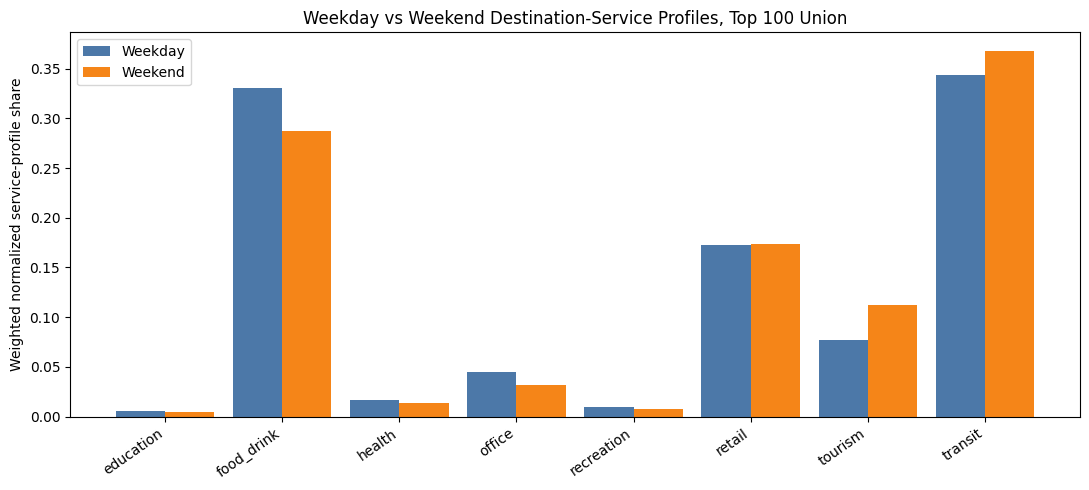

Figure interpretation: Weekend-weighted destinations are higher where the orange bars exceed the blue bars. Weekday-weighted destinations are higher where the blue bars exceed the orange bars. This descriptive comparison is limited to stations with interpretable OSM service coverage.


Saved figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\weekend_minus_weekday_service_difference.png


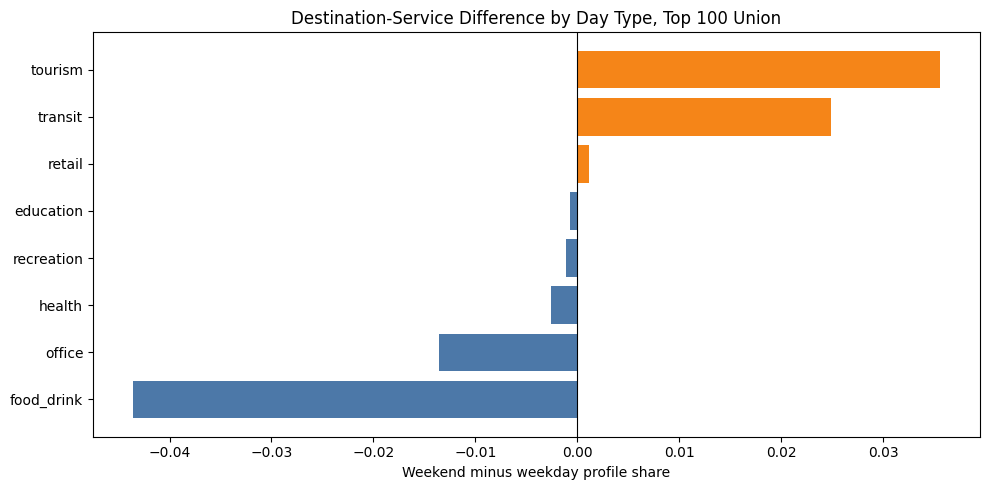

Figure interpretation: Positive values are weekend-oriented services and negative values are weekday-oriented services. These are descriptive profile differences, not causal estimates of rider intent.


In [14]:
weekday_profile = compute_weighted_service_profile(profile_df_250, service_cols_250, "return_count_weekday")
weekend_profile = compute_weighted_service_profile(profile_df_250, service_cols_250, "return_count_weekend")
service_profile_comparison = compute_profile_difference(weekday_profile, weekend_profile)

save_table(weekday_profile.rename_axis("service_category").reset_index(name="profile_value"), "weekday_service_profile.csv")
save_table(weekend_profile.rename_axis("service_category").reset_index(name="profile_value"), "weekend_service_profile.csv")
save_table(service_profile_comparison, "weekday_weekend_service_profile_comparison.csv")
display(service_profile_comparison)

plot_df = service_profile_comparison.sort_values("service_category")
x = np.arange(len(plot_df))
width = 0.42
plt.figure(figsize=(11, 5))
plt.bar(x - width / 2, plot_df["weekday_profile"], width, label="Weekday", color="#4C78A8")
plt.bar(x + width / 2, plot_df["weekend_profile"], width, label="Weekend", color="#F58518")
plt.xticks(x, plot_df["service_category"], rotation=35, ha="right")
plt.ylabel("Weighted normalized service-profile share")
plt.title("Weekday vs Weekend Destination-Service Profiles, Top 100 Union")
plt.legend()
save_figure("weekday_vs_weekend_service_profile.png")
plt.show()

print(
    "Figure interpretation: Weekend-weighted destinations are higher where the orange bars exceed the blue bars. "
    "Weekday-weighted destinations are higher where the blue bars exceed the orange bars. "
    "This descriptive comparison is limited to stations with interpretable OSM service coverage."
)

plt.figure(figsize=(10, 5))
diff_df = service_profile_comparison.sort_values("weekend_minus_weekday")
colors = np.where(diff_df["weekend_minus_weekday"] >= 0, "#F58518", "#4C78A8")
plt.barh(diff_df["service_category"], diff_df["weekend_minus_weekday"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Weekend minus weekday profile share")
plt.title("Destination-Service Difference by Day Type, Top 100 Union")
save_figure("weekend_minus_weekday_service_difference.png")
plt.show()

print(
    "Figure interpretation: Positive values are weekend-oriented services and negative values are weekday-oriented services. "
    "These are descriptive profile differences, not causal estimates of rider intent."
)


**Main profile interpretation.**

- **Purpose:** Test whether weekday- and weekend-weighted destinations have different OSM service environments.
- **Result:** In the Top 100 coordinate-based profile, weekend-weighted destinations are more associated with `tourism` and descriptively with `transit`. Weekday-weighted destinations are more associated with `food_drink` and `office`.
- **Interpretation:** `tourism`, `food_drink`, and `office` are the safest categories to emphasize because bootstrap validation supports their direction. `transit` is descriptively weekend-oriented here, but its bootstrap confidence interval crosses zero, so it should be interpreted cautiously.


## Validation

This is not a prediction model, so validation does not report accuracy, precision, or recall.

Validation is organized as a defend system:

1. **Spatial difference:** Are weekday/weekend destination patterns different?
2. **Null-model strength:** Is the observed service-profile difference larger than reasonable random alternatives?
3. **Service-level stability:** Are the category-level directions stable?
4. **Influence and coverage:** Are results driven by one station or by missing OSM coverage?
5. **Method sensitivity:** Are results sensitive to radius, Top-K, service-vector normalization, or category inclusion?
6. **Weather secondary check:** Are weather effects strong enough to affect the main conclusion?

The goal is to identify which claims are supported, which are weak, and which should be framed cautiously.


## Validation Overview

The detailed validation tables below answer different questions. The final validation overview table is saved after all validation tests have run, because it summarizes computed results rather than planned tests.


Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\validation_shuffle_test_summary.csv
Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\shuffle_test_results.csv
Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\shuffle_test_distribution.csv


,metric,value
0,real_difference_score,0.1231
1,shuffle_mean,0.1015
2,shuffle_95th_percentile,0.1783
3,p_value,0.2657
4,n_shuffles,"1,000.0000"


Saved figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\validation_shuffle_test_histogram.png
Saved figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\shuffle_test_plot.png


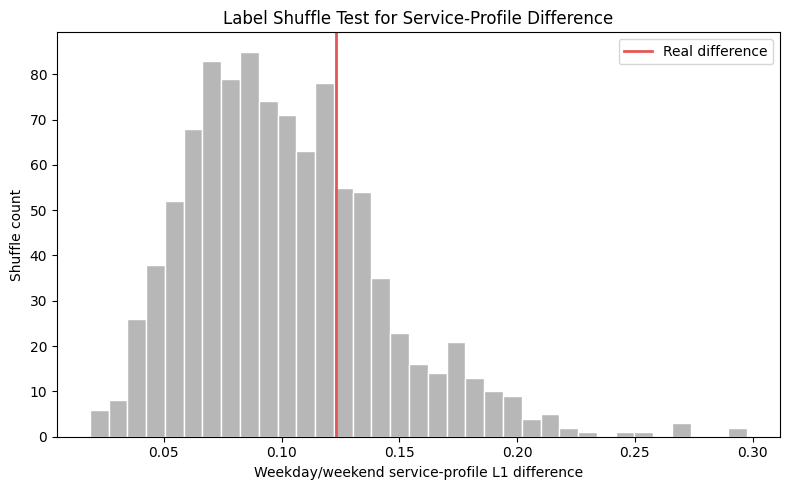

Validation interpretation: If the p-value is not below 0.05, the overall profile difference should not be claimed as statistically significant under this label-shuffle null model.


Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\station_service_permutation_results.csv
Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\station_service_permutation_distribution.csv


,metric,value
0,real_difference_score,0.1231
1,permutation_mean,0.0366
2,permutation_95th_percentile,0.0642
3,p_value,0.0010
4,n_permutations,"1,000.0000"


Saved figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\station_service_permutation_plot.png


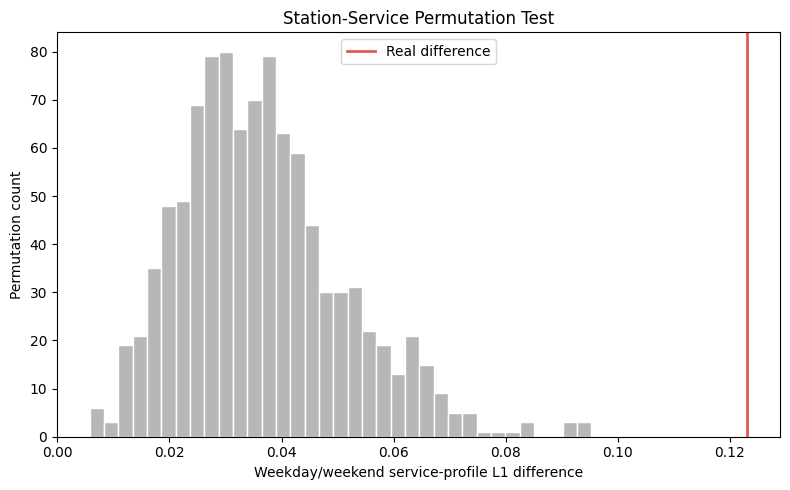

Validation interpretation: This null keeps station demand fixed but breaks the observed pairing between stations and service environments. A small p-value suggests the real station-service pairing is more structured than random service assignment.


Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\bootstrap_service_difference_ci.csv


,service_category,observed_weekend_minus_weekday,bootstrap_ci_low,bootstrap_median,bootstrap_ci_high,n_bootstraps,ci_excludes_zero
0,tourism,0.0355,0.0133,0.0345,0.0566,1000,True
1,transit,0.0248,-0.0021,0.0240,0.0487,1000,False
2,retail,0.0011,-0.0155,0.0007,0.0245,1000,False
3,education,-0.0008,-0.0018,-0.0008,0.0003,1000,False
4,recreation,-0.0011,-0.0024,-0.0011,0.0003,1000,False
5,health,-0.0026,-0.0043,-0.0024,-0.0005,1000,True
6,office,-0.0135,-0.0179,-0.0133,-0.0091,1000,True
7,food_drink,-0.0436,-0.0640,-0.0426,-0.0210,1000,True


Saved figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\bootstrap_service_difference_ci.png


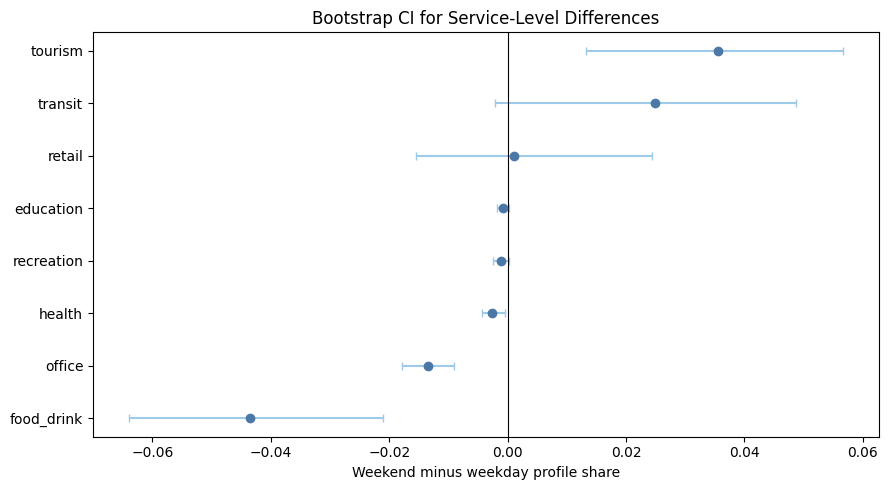

Validation interpretation: Bootstrap intervals show which service-level directions are stable under station resampling. Intervals crossing zero should be interpreted cautiously.


In [15]:
def service_difference_score(weekday, weekend):
    common = weekday.index.intersection(weekend.index)
    return float(np.abs(weekend.loc[common] - weekday.loc[common]).sum())


def profile_from_long_rows(long_df, day_type):
    group = long_df[long_df["day_type"] == day_type]
    return compute_weighted_service_profile(group, service_cols_250, "return_count")


real_difference_score = service_difference_score(weekday_profile, weekend_profile)
long_profile_rows = []
for _, row in profile_df_250.iterrows():
    for day_type, count_col in [("weekday", "return_count_weekday"), ("weekend", "return_count_weekend")]:
        item = row.copy()
        item["day_type"] = day_type
        item["return_count"] = row[count_col]
        long_profile_rows.append(item)
profile_long = pd.DataFrame(long_profile_rows)
original_labels = profile_long["day_type"].to_numpy(copy=True)

rng = np.random.default_rng(RANDOM_SEED)
shuffle_scores = []
for _ in range(N_SHUFFLES):
    shuffled = profile_long.copy()
    shuffled["day_type"] = rng.permutation(original_labels)
    shuffled_weekday = profile_from_long_rows(shuffled, "weekday")
    shuffled_weekend = profile_from_long_rows(shuffled, "weekend")
    shuffle_scores.append(service_difference_score(shuffled_weekday, shuffled_weekend))

shuffle_scores = np.array(shuffle_scores)
shuffle_p_value = (np.sum(shuffle_scores >= real_difference_score) + 1) / (N_SHUFFLES + 1)
shuffle_result = pd.DataFrame({
    "metric": ["real_difference_score", "shuffle_mean", "shuffle_95th_percentile", "p_value", "n_shuffles"],
    "value": [real_difference_score, float(shuffle_scores.mean()), float(np.percentile(shuffle_scores, 95)), float(shuffle_p_value), int(N_SHUFFLES)],
})
shuffle_distribution = pd.DataFrame({"shuffle_difference_score": shuffle_scores})
save_table(shuffle_result, "validation_shuffle_test_summary.csv")
save_table(shuffle_result, "shuffle_test_results.csv")
save_table(shuffle_distribution, "shuffle_test_distribution.csv")
display(shuffle_result)

plt.figure(figsize=(8, 5))
plt.hist(shuffle_scores, bins=35, color="#B7B7B7", edgecolor="white")
plt.axvline(real_difference_score, color="#E45756", linewidth=2, label="Real difference")
plt.xlabel("Weekday/weekend service-profile L1 difference")
plt.ylabel("Shuffle count")
plt.title("Label Shuffle Test for Service-Profile Difference")
plt.legend()
save_figure("validation_shuffle_test_histogram.png")
save_figure("shuffle_test_plot.png")
plt.show()

print(
    "Validation interpretation: If the p-value is not below 0.05, the overall profile difference should not be claimed as statistically significant under this label-shuffle null model."
)

# Station-service permutation test.
service_matrix = profile_df_250[service_cols_250].to_numpy(copy=True)
permutation_scores = []
for _ in range(N_SHUFFLES):
    permuted = profile_df_250.copy()
    permuted.loc[:, service_cols_250] = service_matrix[rng.permutation(len(profile_df_250))]
    perm_weekday = compute_weighted_service_profile(permuted, service_cols_250, "return_count_weekday")
    perm_weekend = compute_weighted_service_profile(permuted, service_cols_250, "return_count_weekend")
    permutation_scores.append(service_difference_score(perm_weekday, perm_weekend))

permutation_scores = np.array(permutation_scores)
permutation_p_value = (np.sum(permutation_scores >= real_difference_score) + 1) / (N_SHUFFLES + 1)
permutation_result = pd.DataFrame({
    "metric": ["real_difference_score", "permutation_mean", "permutation_95th_percentile", "p_value", "n_permutations"],
    "value": [
        real_difference_score,
        float(permutation_scores.mean()),
        float(np.percentile(permutation_scores, 95)),
        float(permutation_p_value),
        int(N_SHUFFLES),
    ],
})
save_table(permutation_result, "station_service_permutation_results.csv")
save_table(pd.DataFrame({"permutation_difference_score": permutation_scores}), "station_service_permutation_distribution.csv")
display(permutation_result)

plt.figure(figsize=(8, 5))
plt.hist(permutation_scores, bins=35, color="#B7B7B7", edgecolor="white")
plt.axvline(real_difference_score, color="#E45756", linewidth=2, label="Real difference")
plt.xlabel("Weekday/weekend service-profile L1 difference")
plt.ylabel("Permutation count")
plt.title("Station-Service Permutation Test")
plt.legend()
save_figure("station_service_permutation_plot.png")
plt.show()

print(
    "Validation interpretation: This null keeps station demand fixed but breaks the observed pairing between stations and service environments. "
    "A small p-value suggests the real station-service pairing is more structured than random service assignment."
)

# Bootstrap confidence intervals for service-level weekend-minus-weekday values.
bootstrap_rows = []
for _ in range(N_BOOTSTRAPS):
    sample_index = rng.integers(0, len(profile_df_250), size=len(profile_df_250))
    bootstrap_sample = profile_df_250.iloc[sample_index].copy()
    boot_weekday = compute_weighted_service_profile(bootstrap_sample, service_cols_250, "return_count_weekday")
    boot_weekend = compute_weighted_service_profile(bootstrap_sample, service_cols_250, "return_count_weekend")
    bootstrap_rows.append((boot_weekend - boot_weekday).to_dict())

bootstrap_diffs = pd.DataFrame(bootstrap_rows)
bootstrap_ci = pd.DataFrame({
    "service_category": service_cols_250,
    "observed_weekend_minus_weekday": [service_profile_comparison.set_index("service_category").loc[c, "weekend_minus_weekday"] for c in service_cols_250],
    "bootstrap_ci_low": [float(np.percentile(bootstrap_diffs[c], 2.5)) for c in service_cols_250],
    "bootstrap_median": [float(np.percentile(bootstrap_diffs[c], 50)) for c in service_cols_250],
    "bootstrap_ci_high": [float(np.percentile(bootstrap_diffs[c], 97.5)) for c in service_cols_250],
    "n_bootstraps": N_BOOTSTRAPS,
})
bootstrap_ci["ci_excludes_zero"] = (
    (bootstrap_ci["bootstrap_ci_low"] > 0) | (bootstrap_ci["bootstrap_ci_high"] < 0)
)
bootstrap_ci = bootstrap_ci.sort_values("observed_weekend_minus_weekday", ascending=False).reset_index(drop=True)
save_table(bootstrap_ci, "bootstrap_service_difference_ci.csv")
display(bootstrap_ci)

plot_ci = bootstrap_ci.sort_values("observed_weekend_minus_weekday")
plt.figure(figsize=(9, 5))
plt.errorbar(
    plot_ci["observed_weekend_minus_weekday"],
    plot_ci["service_category"],
    xerr=[
        plot_ci["observed_weekend_minus_weekday"] - plot_ci["bootstrap_ci_low"],
        plot_ci["bootstrap_ci_high"] - plot_ci["observed_weekend_minus_weekday"],
    ],
    fmt="o",
    color="#4C78A8",
    ecolor="#9ECAE9",
    capsize=3,
)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Weekend minus weekday profile share")
plt.title("Bootstrap CI for Service-Level Differences")
save_figure("bootstrap_service_difference_ci.png")
plt.show()

print(
    "Validation interpretation: Bootstrap intervals show which service-level directions are stable under station resampling. "
    "Intervals crossing zero should be interpreted cautiously."
)


**Station-demand randomization test.**

- **Purpose:** Test whether the observed weekday/weekend service-profile difference could arise if every station kept its total return volume, but weekday/weekend returns were randomly assigned according to the global weekday share.
- **Null model:** `sim_weekday_i ~ Binomial(total_i, global_weekday_share)` and `sim_weekend_i = total_i - sim_weekday_i`.
- **Interpretation:** A small p-value means the observed profile difference is larger than expected from random weekday/weekend assignment while preserving station totals. This supports structured temporal allocation under this null, but it does not prove that OSM services explain rider behavior. A large p-value means this null does not support overall significance.


Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\station_demand_randomization_results.csv
Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\station_demand_randomization_distribution.csv


,metric,value
0,real_difference_score,0.1231
1,randomization_mean,0.0010
2,randomization_95th_percentile,0.0018
3,p_value,0.0010
4,n_randomizations,"1,000.0000"
5,global_weekday_share,0.7356


Saved figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\station_demand_randomization_plot.png


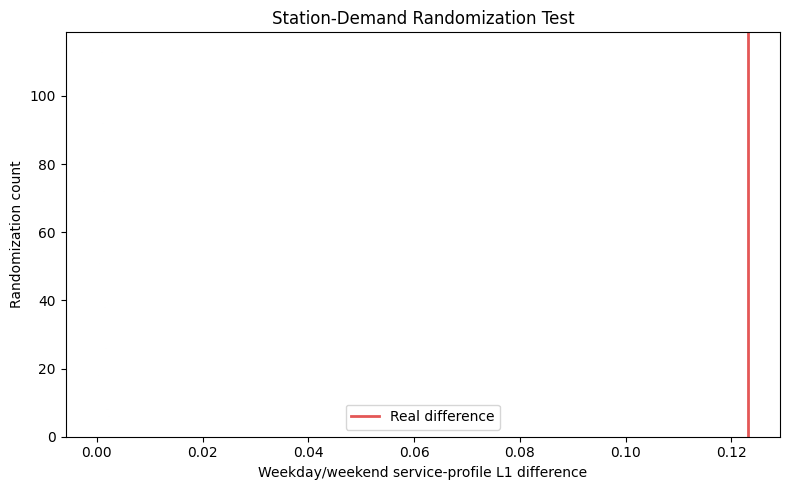

In [16]:
global_weekday_share = profile_df_250["return_count_weekday"].sum() / (
    profile_df_250["return_count_weekday"].sum() + profile_df_250["return_count_weekend"].sum()
)

rng = np.random.default_rng(RANDOM_SEED + 101)
randomization_scores = []
randomization_category_rows = []
for simulation_id in range(N_RANDOMIZATIONS):
    simulated = profile_df_250.copy()
    station_totals = (
        simulated["return_count_weekday"].astype(int)
        + simulated["return_count_weekend"].astype(int)
    )
    simulated_weekday = rng.binomial(station_totals.to_numpy(), global_weekday_share)
    simulated["return_count_weekday"] = simulated_weekday
    simulated["return_count_weekend"] = station_totals.to_numpy() - simulated_weekday

    sim_weekday_profile = compute_weighted_service_profile(simulated, service_cols_250, "return_count_weekday")
    sim_weekend_profile = compute_weighted_service_profile(simulated, service_cols_250, "return_count_weekend")
    sim_diff = sim_weekend_profile - sim_weekday_profile
    sim_score = service_difference_score(sim_weekday_profile, sim_weekend_profile)
    randomization_scores.append(sim_score)

    row = {"simulation_id": simulation_id, "difference_score": sim_score}
    for service_category in service_cols_250:
        row[f"{service_category}_diff"] = sim_diff[service_category]
    randomization_category_rows.append(row)

randomization_scores = np.array(randomization_scores)
demand_randomization_p_value = (
    np.sum(randomization_scores >= real_difference_score) + 1
) / (N_RANDOMIZATIONS + 1)
station_demand_randomization_results = pd.DataFrame({
    "metric": [
        "real_difference_score",
        "randomization_mean",
        "randomization_95th_percentile",
        "p_value",
        "n_randomizations",
        "global_weekday_share",
    ],
    "value": [
        real_difference_score,
        float(randomization_scores.mean()),
        float(np.percentile(randomization_scores, 95)),
        float(demand_randomization_p_value),
        int(N_RANDOMIZATIONS),
        float(global_weekday_share),
    ],
})
station_demand_randomization_distribution = pd.DataFrame(randomization_category_rows)
save_table(station_demand_randomization_results, "station_demand_randomization_results.csv")
save_table(station_demand_randomization_distribution, "station_demand_randomization_distribution.csv")
display(station_demand_randomization_results)

plt.figure(figsize=(8, 5))
plt.hist(randomization_scores, bins=35, color="#B7B7B7", edgecolor="white")
plt.axvline(real_difference_score, color="#E45756", linewidth=2, label="Real difference")
plt.xlabel("Weekday/weekend service-profile L1 difference")
plt.ylabel("Randomization count")
plt.title("Station-Demand Randomization Test")
plt.legend()
save_figure("station_demand_randomization_plot.png")
plt.show()


**Validation interpretation: shuffle, permutation, and bootstrap.**

- **Purpose:** Test whether the profile difference is stronger than simple random alternatives and whether service-level directions are stable.
- **Result:** The label shuffle test does not support overall statistical significance at the 0.05 level. The station-service permutation test shows that real station-service pairing is more structured than random service-vector assignment. Bootstrap intervals support stable directions for `tourism`, `food_drink`, `office`, and `health`.
- **Interpretation:** The final claim should be exploratory and associative. The strongest defensible claim is that some service-level directions are structured and stable, not that the whole weekday/weekend profile difference is conclusively significant under every null model.


Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\validation_radius_sensitivity_summary.csv
Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\radius_sensitivity_results.csv
Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\validation_radius_sensitivity_service_details.csv


,radius_m,profile_difference_l1,stations_used,covered_return_share,most_weekend_oriented_service,most_weekday_oriented_service
0,100,0.1344,72,0.6110,transit,food_drink
1,250,0.1231,75,0.6363,tourism,food_drink
2,500,0.0885,77,0.6527,tourism,food_drink


Saved figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\validation_radius_sensitivity.png


Saved figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\radius_sensitivity_plot.png


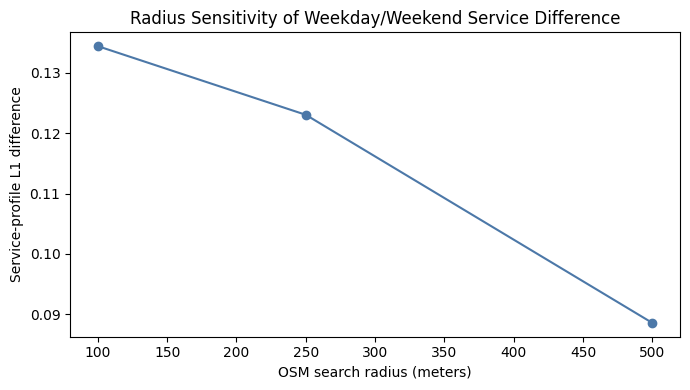

Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\topk_sensitivity_results.csv
Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\validation_topk_sensitivity_service_details.csv


,topk_union,union_station_count,stations_used,station_coverage_share,covered_return_share,profile_difference_l1,most_weekend_oriented_service,most_weekday_oriented_service,osm_radius_m
0,20,29,24,0.8276,0.8527,0.1933,tourism,food_drink,250
1,50,72,45,0.6250,0.6856,0.1499,tourism,food_drink,250
2,100,129,75,0.5814,0.6363,0.1231,tourism,food_drink,250


Saved figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\topk_sensitivity_plot.png


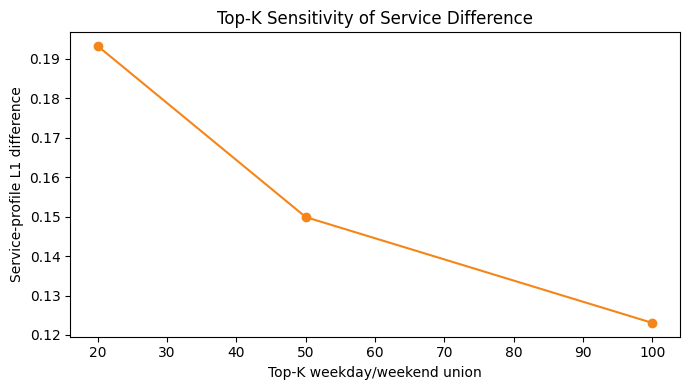

Validation interpretation: Radius and Top-K checks show whether conclusions depend on one modeling choice. Changes across radius or K should be reported as scale sensitivity, not hidden.


In [17]:
radius_rows = []
radius_detail_rows = []
for radius in RADIUS_LIST:
    service_counts_r = service_counts_all_radii[radius].copy()
    profile_df_r, service_cols_r = prepare_profile_dataset(main_profile_stations, service_counts_r, interpretable_only=True)
    weekday_r = compute_weighted_service_profile(profile_df_r, service_cols_r, "return_count_weekday")
    weekend_r = compute_weighted_service_profile(profile_df_r, service_cols_r, "return_count_weekend")
    comparison_r = compute_profile_difference(weekday_r, weekend_r)
    score_r = service_difference_score(weekday_r, weekend_r)
    radius_rows.append({
        "radius_m": radius,
        "profile_difference_l1": score_r,
        "stations_used": len(profile_df_r),
        "covered_return_share": profile_df_r["total_return_count"].sum() / main_profile_stations["total_return_count"].sum(),
        "most_weekend_oriented_service": comparison_r.iloc[0]["service_category"],
        "most_weekday_oriented_service": comparison_r.iloc[-1]["service_category"],
    })
    for _, row in comparison_r.iterrows():
        radius_detail_rows.append({
            "radius_m": radius,
            "service_category": row["service_category"],
            "weekday_profile": row["weekday_profile"],
            "weekend_profile": row["weekend_profile"],
            "weekend_minus_weekday": row["weekend_minus_weekday"],
        })

radius_sensitivity = pd.DataFrame(radius_rows)
radius_details = pd.DataFrame(radius_detail_rows)
save_table(radius_sensitivity, "validation_radius_sensitivity_summary.csv")
save_table(radius_sensitivity, "radius_sensitivity_results.csv")
save_table(radius_details, "validation_radius_sensitivity_service_details.csv")
display(radius_sensitivity)

plt.figure(figsize=(7, 4))
plt.plot(radius_sensitivity["radius_m"], radius_sensitivity["profile_difference_l1"], marker="o", color="#4C78A8")
plt.xlabel("OSM search radius (meters)")
plt.ylabel("Service-profile L1 difference")
plt.title("Radius Sensitivity of Weekday/Weekend Service Difference")
save_figure("validation_radius_sensitivity.png")
save_figure("radius_sensitivity_plot.png")
plt.show()

topk_rows = []
topk_detail_rows = []
for k in TOPK_LIST:
    counts_k = osm_service_counts_by_topk_radius[(k, OSM_RADIUS_MAIN)].copy()
    stations_k = topk_union_sets[k].copy()
    profile_df_k, service_cols_k = prepare_profile_dataset(stations_k, counts_k, interpretable_only=True)
    weekday_k = compute_weighted_service_profile(profile_df_k, service_cols_k, "return_count_weekday")
    weekend_k = compute_weighted_service_profile(profile_df_k, service_cols_k, "return_count_weekend")
    comparison_k = compute_profile_difference(weekday_k, weekend_k)
    score_k = service_difference_score(weekday_k, weekend_k)
    topk_rows.append({
        "topk_union": k,
        "union_station_count": len(stations_k),
        "stations_used": len(profile_df_k),
        "station_coverage_share": len(profile_df_k) / len(stations_k),
        "covered_return_share": profile_df_k["total_return_count"].sum() / stations_k["total_return_count"].sum(),
        "profile_difference_l1": score_k,
        "most_weekend_oriented_service": comparison_k.iloc[0]["service_category"],
        "most_weekday_oriented_service": comparison_k.iloc[-1]["service_category"],
        "osm_radius_m": OSM_RADIUS_MAIN,
    })
    for _, row in comparison_k.iterrows():
        topk_detail_rows.append({
            "topk_union": k,
            "service_category": row["service_category"],
            "weekday_profile": row["weekday_profile"],
            "weekend_profile": row["weekend_profile"],
            "weekend_minus_weekday": row["weekend_minus_weekday"],
        })

topk_sensitivity = pd.DataFrame(topk_rows)
topk_details = pd.DataFrame(topk_detail_rows)
save_table(topk_sensitivity, "topk_sensitivity_results.csv")
save_table(topk_details, "validation_topk_sensitivity_service_details.csv")
display(topk_sensitivity)

plt.figure(figsize=(7, 4))
plt.plot(topk_sensitivity["topk_union"], topk_sensitivity["profile_difference_l1"], marker="o", color="#F58518")
plt.xlabel("Top-K weekday/weekend union")
plt.ylabel("Service-profile L1 difference")
plt.title("Top-K Sensitivity of Service Difference")
save_figure("topk_sensitivity_plot.png")
plt.show()

print(
    "Validation interpretation: Radius and Top-K checks show whether conclusions depend on one modeling choice. "
    "Changes across radius or K should be reported as scale sensitivity, not hidden."
)


**Influence, coverage, and method sensitivity checks.**

These tests check whether the result is driven by one station, missing OSM coverage, radius/Top-K choices, service-vector normalization, or category inclusion decisions.


Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\leave_one_station_out_influence.csv
Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\top_influential_stations.csv


,removed_station,removed_lat,removed_lng,removed_total_returns,removed_weekday_returns,removed_weekend_returns,removed_weekend_share,original_l1,l1_after_removal,delta_l1,...,food_drink_diff_after_removal,delta_food_drink_diff,original_office_diff,office_diff_after_removal,delta_office_diff,original_transit_diff,transit_diff_after_removal,delta_transit_diff,abs_delta_l1,abs_delta_tourism_diff
22,Dusable Harbor,41.8870,-87.6128,"20,493.0000","11,732.0000","8,761.0000",0.4275,0.1231,0.1159,-0.0072,...,-0.0405,0.0031,-0.0135,-0.0133,0.0002,0.0248,0.0274,0.0026,0.0072,0.0061
21,DuSable Lake Shore Dr & North Blvd,41.9117,-87.6268,"34,670.0000","19,730.0000","14,940.0000",0.4309,0.1231,0.1103,-0.0128,...,-0.0381,0.0055,-0.0135,-0.0131,0.0004,0.0248,0.0202,-0.0046,0.0128,0.0056
59,Shedd Aquarium,41.8672,-87.6154,"19,506.0000","11,191.0000","8,315.0000",0.4263,0.1231,0.1197,-0.0034,...,-0.0423,0.0012,-0.0135,-0.0133,0.0002,0.0248,0.0266,0.0018,0.0034,0.0055
20,DuSable Lake Shore Dr & Monroe St,41.8810,-87.6167,"37,916.0000","20,698.0000","17,218.0000",0.4541,0.1231,0.1065,-0.0165,...,-0.0365,0.0070,-0.0135,-0.0129,0.0006,0.0248,0.0148,-0.0100,0.0165,0.0031
26,Field Museum,41.8653,-87.6179,"10,128.0000","5,521.0000","4,607.0000",0.4549,0.1231,0.1189,-0.0042,...,-0.0418,0.0018,-0.0135,-0.0134,0.0001,0.0248,0.0244,-0.0004,0.0042,0.0029
46,Michigan Ave & Oak St,41.9010,-87.6238,"34,628.0000","21,157.0000","13,471.0000",0.3890,0.1231,0.1346,0.0115,...,-0.0428,0.0007,-0.0135,-0.0138,-0.0003,0.0248,0.0295,0.0047,0.0115,0.0022
51,Morgan St & Polk St,41.8717,-87.6510,"10,830.0000","9,246.0000","1,584.0000",0.1463,0.1231,0.1240,0.0009,...,-0.0436,-0.0000,-0.0135,-0.0138,-0.0003,0.0248,0.0242,-0.0006,0.0009,0.0015
68,Wells St & Concord Ln,41.9121,-87.6347,"27,535.0000","18,316.0000","9,219.0000",0.3348,0.1231,0.1268,0.0038,...,-0.0452,-0.0017,-0.0135,-0.0137,-0.0002,0.0248,0.0256,0.0008,0.0038,0.0014
52,Navy Pier,41.8923,-87.6120,"34,777.0000","19,160.0000","15,617.0000",0.4491,0.1231,0.1176,-0.0054,...,-0.0419,0.0016,-0.0135,-0.0130,0.0005,0.0248,0.0213,-0.0035,0.0054,0.0012
69,Wells St & Elm St,41.9032,-87.6343,"26,237.0000","18,124.0000","8,113.0000",0.3092,0.1231,0.1252,0.0021,...,-0.0445,-0.0009,-0.0135,-0.0137,-0.0002,0.0248,0.0249,0.0001,0.0021,0.0011


Saved figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\leave_one_station_out_tourism_influence.png


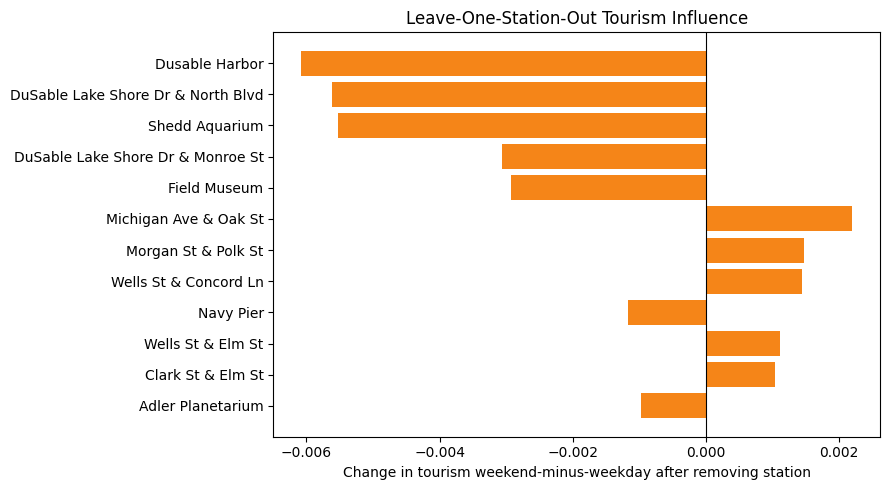

Saved figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\leave_one_station_out_food_drink_influence.png


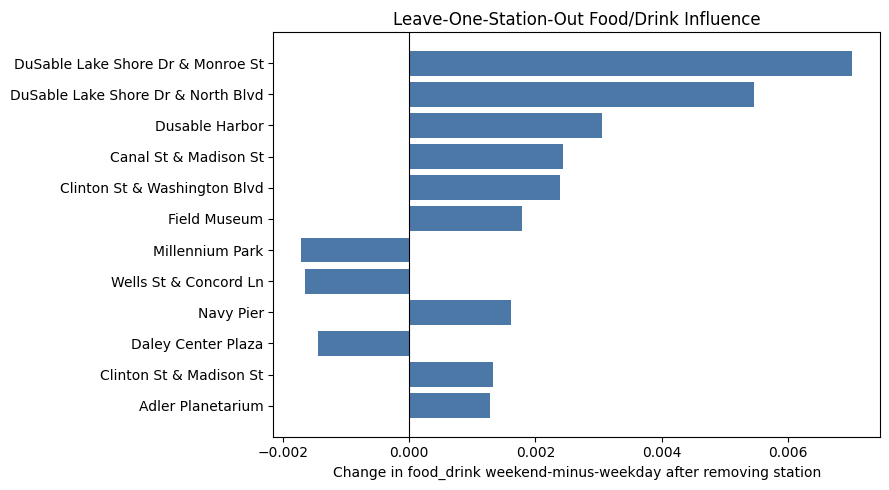

Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\osm_coverage_bias_summary.csv
Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\osm_uncovered_top_stations.csv


,topk_union,union_station_count,covered_station_count,uncovered_station_count,covered_return_share,uncovered_return_share,covered_weekday_return_share,covered_weekend_return_share,uncovered_weekday_return_share,uncovered_weekend_return_share,mean_lat_covered,mean_lng_covered,mean_lat_uncovered,mean_lng_uncovered,top_uncovered_stations_by_total_returns
0,20,29,24,5,0.8527,0.1473,0.8739,0.8025,0.1261,0.1975,41.8888,-87.6288,41.9314,-87.6353,Theater on the Lake; Clark St & Armitage Ave; ...
1,50,72,45,27,0.6856,0.3144,0.7069,0.6330,0.2931,0.3670,41.8875,-87.6294,41.9228,-87.6409,Theater on the Lake; Clark St & Armitage Ave; ...
2,100,129,75,54,0.6363,0.3637,0.6565,0.5859,0.3435,0.4141,41.8876,-87.6309,41.9258,-87.6461,Theater on the Lake; Clark St & Armitage Ave; ...


Saved figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\covered_vs_uncovered_return_share.png


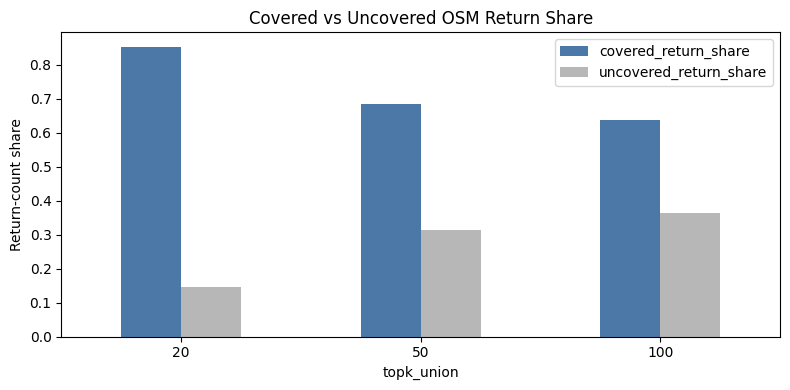

Saved figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\covered_vs_uncovered_weekday_weekend_share.png


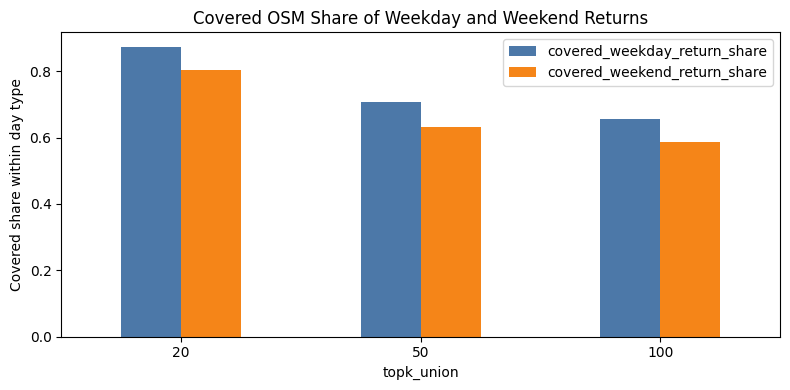

Saved coverage map: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\covered_vs_uncovered_station_map.html


Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\topk_radius_sensitivity_grid.csv


,topk_union,radius_m,union_station_count,stations_used,covered_return_share,profile_difference_l1,top_weekend_oriented_service,top_weekday_oriented_service,education_diff,food_drink_diff,health_diff,office_diff,recreation_diff,retail_diff,tourism_diff,transit_diff
0,20,100,29,23,0.8073,0.2125,transit,food_drink,0.0010,-0.0642,-0.0057,-0.0090,-0.0031,-0.0242,0.0289,0.0763
1,20,250,29,24,0.8527,0.1933,tourism,food_drink,-0.0011,-0.0742,-0.0039,-0.0155,-0.0019,0.0050,0.0627,0.0289
2,20,500,29,25,0.8834,0.1445,tourism,food_drink,-0.0013,-0.0461,0.0012,-0.0151,-0.0018,-0.0080,0.0374,0.0336
3,50,100,72,44,0.6629,0.1718,transit,food_drink,0.0013,-0.0451,-0.0032,-0.0119,-0.0011,-0.0246,0.0245,0.0601
4,50,250,72,45,0.6856,0.1499,tourism,food_drink,-0.0004,-0.0533,-0.0038,-0.0155,-0.0017,-0.0002,0.0460,0.0290
5,50,500,72,46,0.7010,0.1107,tourism,food_drink,-0.0010,-0.0334,0.0006,-0.0133,-0.0012,-0.0065,0.0284,0.0264
6,100,100,129,72,0.6110,0.1344,transit,food_drink,0.0010,-0.0383,-0.0023,-0.0112,-0.0011,-0.0144,0.0153,0.0509
7,100,250,129,75,0.6363,0.1231,tourism,food_drink,-0.0008,-0.0436,-0.0026,-0.0135,-0.0011,0.0011,0.0355,0.0248
8,100,500,129,77,0.6527,0.0885,tourism,food_drink,-0.0009,-0.0274,0.0004,-0.0109,-0.0010,-0.0040,0.0234,0.0204


Saved figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\topk_radius_l1_heatmap.png


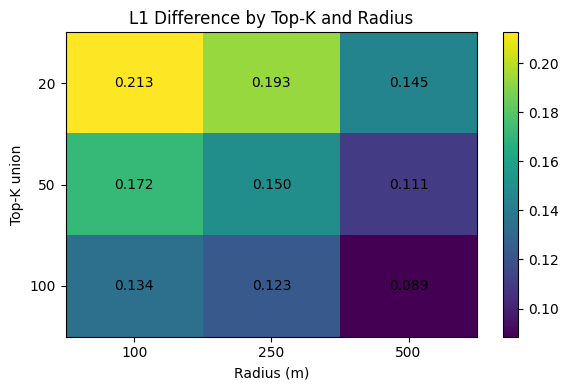

Saved figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\topk_radius_tourism_diff_heatmap.png


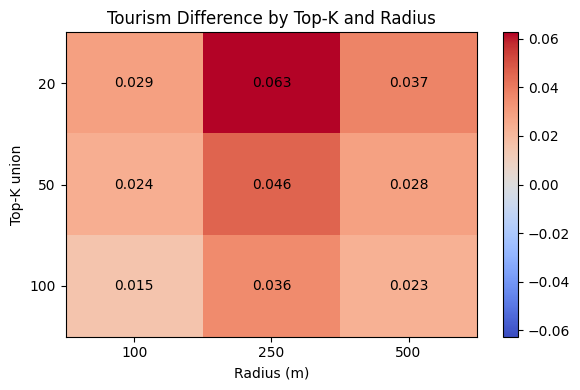

Saved figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\topk_radius_food_drink_diff_heatmap.png


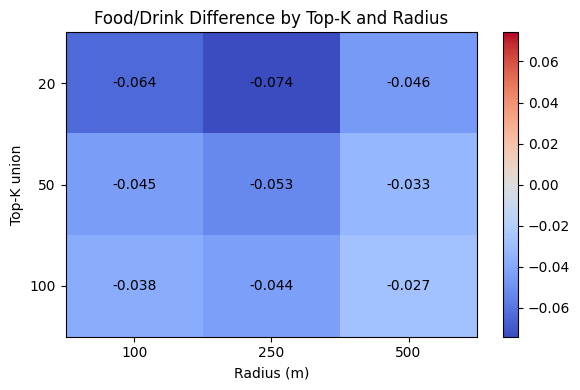

Saved figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\topk_radius_office_diff_heatmap.png


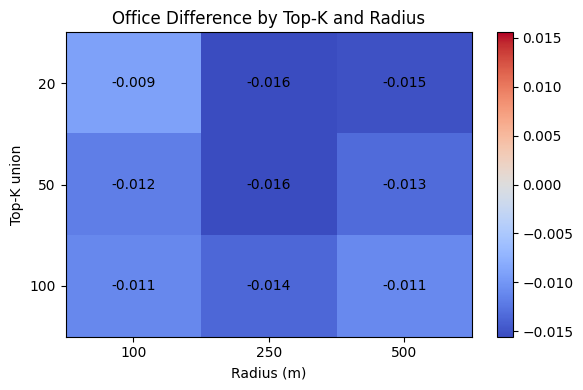

Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\service_vector_normalization_sensitivity.csv


,model_variant,profile_difference_l1,top_weekend_oriented_service,top_weekday_oriented_service,education_diff,food_drink_diff,health_diff,office_diff,recreation_diff,retail_diff,tourism_diff,transit_diff
0,composition,0.1231,tourism,food_drink,-0.0008,-0.0436,-0.0026,-0.0135,-0.0011,0.0011,0.0355,0.0248
1,intensity,0.0781,retail,food_drink,-0.0001,-0.0189,-0.0006,-0.0114,0.0003,0.0280,0.0108,-0.0081
2,binary_presence,0.0779,transit,health,-0.0029,0.0036,-0.0157,-0.0149,-0.0055,0.0034,0.0132,0.0188


Saved figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\service_vector_normalization_sensitivity.png


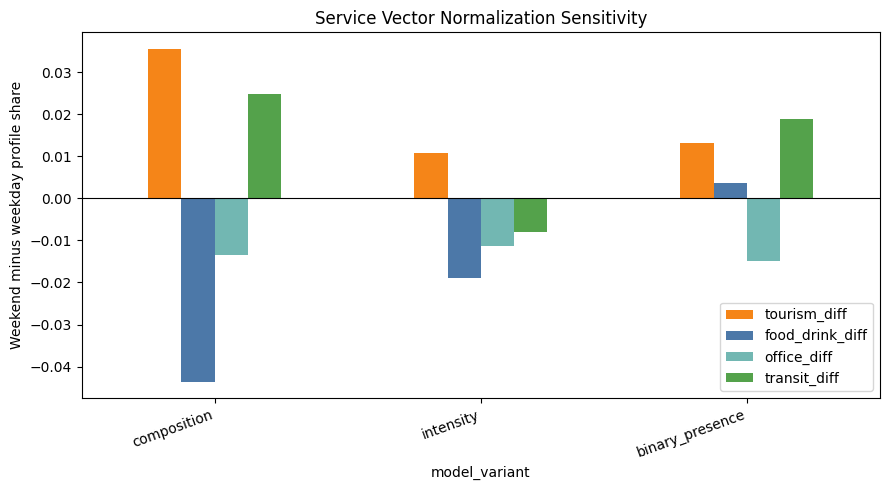

Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\category_inclusion_sensitivity.csv


,category_set,service_categories,stations_used,profile_difference_l1,top_weekend_oriented_service,top_weekday_oriented_service,tourism_diff,food_drink_diff,office_diff,transit_diff,recreation_diff,retail_diff,health_diff,education_diff,other_amenity_diff
0,interpretable_only,"education, food_drink, health, office, recreat...",75,0.1231,tourism,food_drink,0.0355,-0.0436,-0.0135,0.0248,-0.0011,0.0011,-0.0026,-0.0008,NaN
1,interpretable_plus_other,"education, food_drink, health, office, recreat...",75,0.1231,tourism,food_drink,0.0356,-0.0435,-0.0135,0.0249,-0.0011,0.0011,-0.0025,-0.0008,-0.0001
2,without_transit,"education, food_drink, health, office, recreat...",75,0.1706,tourism,food_drink,0.0835,-0.0576,-0.0208,NaN,-0.0016,0.0018,-0.0035,-0.0017,NaN
3,without_transit_plus_other,"education, food_drink, health, office, recreat...",75,0.1706,tourism,food_drink,0.0835,-0.0575,-0.0207,NaN,-0.0016,0.0018,-0.0035,-0.0017,-0.0002


Saved figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\category_inclusion_sensitivity.png


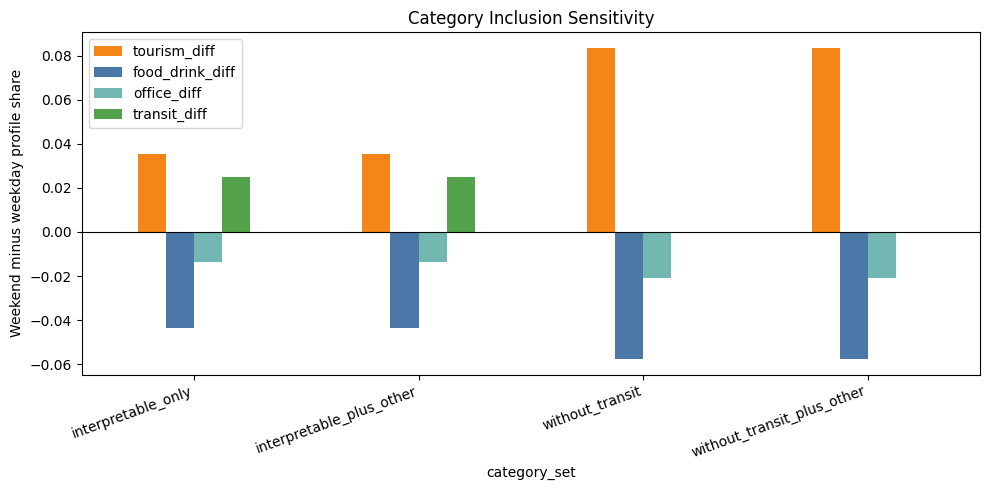

Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\bootstrap_service_category_stability.csv
Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\bootstrap_service_category_fdr.csv


,service_category,observed_diff,bootstrap_mean,ci_low,ci_high,percent_positive,percent_negative,excludes_zero,p_bootstrap_two_sided,q_value_fdr,significant_after_fdr
0,tourism,0.0355,0.0346,0.0133,0.0566,1.0000,0.0000,True,0.0000,0.0000,True
1,transit,0.0248,0.0242,-0.0021,0.0487,0.9620,0.0380,False,0.0760,0.1216,False
2,retail,0.0011,0.0014,-0.0155,0.0245,0.5310,0.4690,False,0.9380,0.9380,False
3,education,-0.0008,-0.0007,-0.0018,0.0003,0.0780,0.9220,False,0.1560,0.1783,False
4,recreation,-0.0011,-0.0011,-0.0024,0.0003,0.0510,0.9490,False,0.1020,0.1360,False
5,health,-0.0026,-0.0024,-0.0043,-0.0005,0.0110,0.9890,True,0.0220,0.0440,True
6,office,-0.0135,-0.0133,-0.0179,-0.0091,0.0000,1.0000,True,0.0000,0.0000,True
7,food_drink,-0.0436,-0.0425,-0.0640,-0.0210,0.0000,1.0000,True,0.0000,0.0000,True


Saved figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\bootstrap_service_category_ci.png


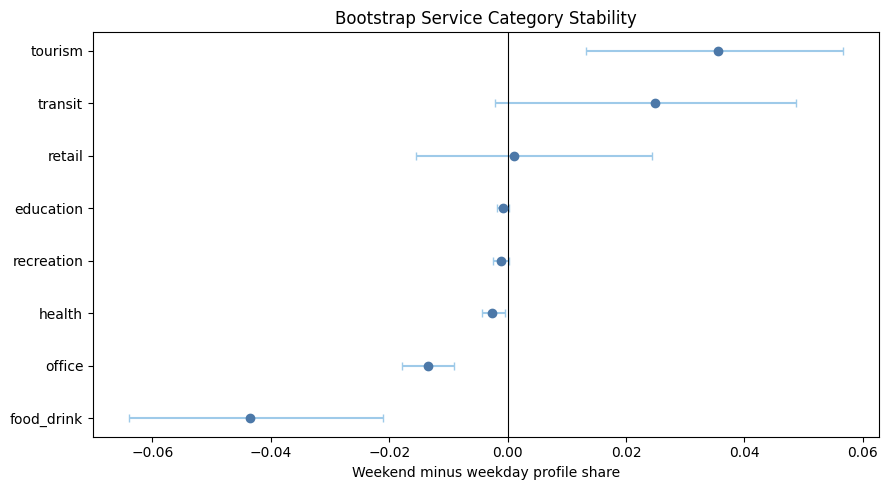

In [18]:
original_diff = service_profile_comparison.set_index("service_category")["weekend_minus_weekday"]

# Leave-one-station-out influence test.
influence_rows = []
for _, removed in profile_df_250.iterrows():
    reduced = profile_df_250[profile_df_250["end_station_name"] != removed["end_station_name"]].copy()
    reduced_weekday = compute_weighted_service_profile(reduced, service_cols_250, "return_count_weekday")
    reduced_weekend = compute_weighted_service_profile(reduced, service_cols_250, "return_count_weekend")
    reduced_diff = reduced_weekend - reduced_weekday
    reduced_l1 = service_difference_score(reduced_weekday, reduced_weekend)

    row = {
        "removed_station": removed["end_station_name"],
        "removed_lat": removed["end_lat"],
        "removed_lng": removed["end_lng"],
        "removed_total_returns": removed["total_return_count"],
        "removed_weekday_returns": removed["return_count_weekday"],
        "removed_weekend_returns": removed["return_count_weekend"],
        "removed_weekend_share": removed["return_count_weekend"] / (
            removed["return_count_weekday"] + removed["return_count_weekend"]
        ),
        "original_l1": real_difference_score,
        "l1_after_removal": reduced_l1,
        "delta_l1": reduced_l1 - real_difference_score,
    }
    for category in ["tourism", "food_drink", "office", "transit"]:
        row[f"original_{category}_diff"] = original_diff.get(category, np.nan)
        row[f"{category}_diff_after_removal"] = reduced_diff.get(category, np.nan)
        row[f"delta_{category}_diff"] = reduced_diff.get(category, np.nan) - original_diff.get(category, np.nan)
    influence_rows.append(row)

leave_one_station_out_influence = pd.DataFrame(influence_rows)
top_influential_stations = (
    leave_one_station_out_influence.assign(
        abs_delta_l1=lambda df: df["delta_l1"].abs(),
        abs_delta_tourism_diff=lambda df: df["delta_tourism_diff"].abs(),
    )
    .sort_values(["abs_delta_tourism_diff", "abs_delta_l1"], ascending=False)
    .head(15)
)
save_table(leave_one_station_out_influence, "leave_one_station_out_influence.csv")
save_table(top_influential_stations, "top_influential_stations.csv")
display(top_influential_stations)

top_tourism_influence = leave_one_station_out_influence.nlargest(12, "delta_tourism_diff", keep="all")
plot_tourism = leave_one_station_out_influence.reindex(
    leave_one_station_out_influence["delta_tourism_diff"].abs().sort_values(ascending=False).index
).head(12)
plt.figure(figsize=(9, 5))
plt.barh(plot_tourism["removed_station"], plot_tourism["delta_tourism_diff"], color="#F58518")
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Change in tourism weekend-minus-weekday after removing station")
plt.title("Leave-One-Station-Out Tourism Influence")
plt.gca().invert_yaxis()
save_figure("leave_one_station_out_tourism_influence.png")
plt.show()

plot_food = leave_one_station_out_influence.reindex(
    leave_one_station_out_influence["delta_food_drink_diff"].abs().sort_values(ascending=False).index
).head(12)
plt.figure(figsize=(9, 5))
plt.barh(plot_food["removed_station"], plot_food["delta_food_drink_diff"], color="#4C78A8")
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Change in food_drink weekend-minus-weekday after removing station")
plt.title("Leave-One-Station-Out Food/Drink Influence")
plt.gca().invert_yaxis()
save_figure("leave_one_station_out_food_drink_influence.png")
plt.show()

# OSM coverage bias diagnostics.
coverage_bias_rows = []
uncovered_rows = []
for k in TOPK_LIST:
    counts_k = osm_service_counts_by_topk_radius[(k, OSM_RADIUS_MAIN)].copy()
    counts_k["has_interpretable_osm"] = counts_k["total_services_interpretable"] > 0
    covered = counts_k[counts_k["has_interpretable_osm"]].copy()
    uncovered = counts_k[~counts_k["has_interpretable_osm"]].copy()

    def safe_share(numer, denom):
        return float(numer / denom) if denom else np.nan

    total_weekday_k = counts_k["return_count_weekday"].sum()
    total_weekend_k = counts_k["return_count_weekend"].sum()
    total_return_k = counts_k["total_return_count"].sum()

    coverage_bias_rows.append({
        "topk_union": k,
        "union_station_count": len(counts_k),
        "covered_station_count": len(covered),
        "uncovered_station_count": len(uncovered),
        "covered_return_share": safe_share(covered["total_return_count"].sum(), total_return_k),
        "uncovered_return_share": safe_share(uncovered["total_return_count"].sum(), total_return_k),
        "covered_weekday_return_share": safe_share(covered["return_count_weekday"].sum(), total_weekday_k),
        "covered_weekend_return_share": safe_share(covered["return_count_weekend"].sum(), total_weekend_k),
        "uncovered_weekday_return_share": safe_share(uncovered["return_count_weekday"].sum(), total_weekday_k),
        "uncovered_weekend_return_share": safe_share(uncovered["return_count_weekend"].sum(), total_weekend_k),
        "mean_lat_covered": covered["end_lat"].mean(),
        "mean_lng_covered": covered["end_lng"].mean(),
        "mean_lat_uncovered": uncovered["end_lat"].mean(),
        "mean_lng_uncovered": uncovered["end_lng"].mean(),
        "top_uncovered_stations_by_total_returns": "; ".join(
            uncovered.sort_values("total_return_count", ascending=False)["end_station_name"].head(8).tolist()
        ),
    })

    top_uncovered = uncovered.sort_values("total_return_count", ascending=False).head(20).copy()
    top_uncovered["topk_union"] = k
    uncovered_rows.append(top_uncovered)

osm_coverage_bias_summary = pd.DataFrame(coverage_bias_rows)
osm_uncovered_top_stations = pd.concat(uncovered_rows, ignore_index=True) if uncovered_rows else pd.DataFrame()
save_table(osm_coverage_bias_summary, "osm_coverage_bias_summary.csv")
save_table(osm_uncovered_top_stations, "osm_uncovered_top_stations.csv")
display(osm_coverage_bias_summary)

coverage_plot = osm_coverage_bias_summary[["topk_union", "covered_return_share", "uncovered_return_share"]].set_index("topk_union")
coverage_plot.plot(kind="bar", figsize=(8, 4), color=["#4C78A8", "#B7B7B7"])
plt.ylabel("Return-count share")
plt.title("Covered vs Uncovered OSM Return Share")
plt.xticks(rotation=0)
save_figure("covered_vs_uncovered_return_share.png")
plt.show()

share_plot = osm_coverage_bias_summary[
    ["topk_union", "covered_weekday_return_share", "covered_weekend_return_share"]
].set_index("topk_union")
share_plot.plot(kind="bar", figsize=(8, 4), color=["#4C78A8", "#F58518"])
plt.ylabel("Covered share within day type")
plt.title("Covered OSM Share of Weekday and Weekend Returns")
plt.xticks(rotation=0)
save_figure("covered_vs_uncovered_weekday_weekend_share.png")
plt.show()

try:
    import folium
    map_df = osm_service_counts_by_topk_radius[(MAIN_PROFILE_TOP_K, OSM_RADIUS_MAIN)].copy()
    center = [map_df["end_lat"].mean(), map_df["end_lng"].mean()]
    coverage_map = folium.Map(location=center, zoom_start=11, tiles="CartoDB positron")
    for _, row in map_df.iterrows():
        covered_flag = row["total_services_interpretable"] > 0
        color = "#4C78A8" if covered_flag else "#E45756"
        popup = (
            f"<b>{row['end_station_name']}</b><br>"
            f"Covered: {covered_flag}<br>"
            f"Total returns: {int(row['total_return_count'])}<br>"
            f"Weekday returns: {int(row['return_count_weekday'])}<br>"
            f"Weekend returns: {int(row['return_count_weekend'])}"
        )
        folium.CircleMarker(
            location=[row["end_lat"], row["end_lng"]],
            radius=4 + np.log1p(row["total_return_count"]) / 3,
            color=color,
            fill=True,
            fill_opacity=0.7,
            popup=popup,
        ).add_to(coverage_map)
    coverage_map_path = FINAL_FIGURE_DIR / "covered_vs_uncovered_station_map.html"
    coverage_map.save(str(coverage_map_path))
    print("Saved coverage map:", coverage_map_path)
except Exception as exc:
    print("Skipping coverage map because:", exc)

# Top-K x Radius grid.
grid_rows = []
for k in TOPK_LIST:
    stations_k = topk_union_sets[k].copy()
    for radius in RADIUS_LIST:
        counts_kr = osm_service_counts_by_topk_radius[(k, radius)].copy()
        profile_df_kr, service_cols_kr = prepare_profile_dataset(stations_k, counts_kr, interpretable_only=True)
        weekday_kr = compute_weighted_service_profile(profile_df_kr, service_cols_kr, "return_count_weekday")
        weekend_kr = compute_weighted_service_profile(profile_df_kr, service_cols_kr, "return_count_weekend")
        diff_kr = weekend_kr - weekday_kr
        comp_kr = compute_profile_difference(weekday_kr, weekend_kr)
        row = {
            "topk_union": k,
            "radius_m": radius,
            "union_station_count": len(stations_k),
            "stations_used": len(profile_df_kr),
            "covered_return_share": profile_df_kr["total_return_count"].sum() / stations_k["total_return_count"].sum(),
            "profile_difference_l1": service_difference_score(weekday_kr, weekend_kr),
            "top_weekend_oriented_service": comp_kr.iloc[0]["service_category"],
            "top_weekday_oriented_service": comp_kr.iloc[-1]["service_category"],
        }
        for category in service_cols_kr:
            row[f"{category}_diff"] = diff_kr.get(category, np.nan)
        grid_rows.append(row)
topk_radius_sensitivity_grid = pd.DataFrame(grid_rows)
save_table(topk_radius_sensitivity_grid, "topk_radius_sensitivity_grid.csv")
display(topk_radius_sensitivity_grid)

def plot_grid_metric(metric, filename, title, cmap="viridis", center_zero=False):
    pivot = topk_radius_sensitivity_grid.pivot(index="topk_union", columns="radius_m", values=metric)
    plt.figure(figsize=(6, 4))
    if center_zero:
        vmax = np.nanmax(np.abs(pivot.to_numpy()))
        vmin = -vmax
    else:
        vmin = None
        vmax = None
    im = plt.imshow(pivot.to_numpy(), cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.xlabel("Radius (m)")
    plt.ylabel("Top-K union")
    plt.title(title)
    for i, topk in enumerate(pivot.index):
        for j, radius in enumerate(pivot.columns):
            value = pivot.loc[topk, radius]
            plt.text(j, i, f"{value:.3f}", ha="center", va="center", color="black")
    plt.colorbar(im)
    save_figure(filename)
    plt.show()

plot_grid_metric("profile_difference_l1", "topk_radius_l1_heatmap.png", "L1 Difference by Top-K and Radius")
plot_grid_metric("tourism_diff", "topk_radius_tourism_diff_heatmap.png", "Tourism Difference by Top-K and Radius", cmap="coolwarm", center_zero=True)
plot_grid_metric("food_drink_diff", "topk_radius_food_drink_diff_heatmap.png", "Food/Drink Difference by Top-K and Radius", cmap="coolwarm", center_zero=True)
plot_grid_metric("office_diff", "topk_radius_office_diff_heatmap.png", "Office Difference by Top-K and Radius", cmap="coolwarm", center_zero=True)

# Service vector normalization sensitivity.
def compute_profiles_by_variant(df, service_cols, variant):
    data = df.copy()
    counts = data.set_index("end_station_name")[service_cols].fillna(0).astype(float)
    weekday_weights = data.set_index("end_station_name")["return_count_weekday"].astype(float)
    weekend_weights = data.set_index("end_station_name")["return_count_weekend"].astype(float)

    if variant == "composition":
        matrix = normalize_service_vectors(counts)
        weekday = pd.Series(matrix.to_numpy().T.dot((weekday_weights / weekday_weights.sum()).to_numpy()), index=service_cols)
        weekend = pd.Series(matrix.to_numpy().T.dot((weekend_weights / weekend_weights.sum()).to_numpy()), index=service_cols)
    elif variant == "intensity":
        weekday_raw = counts.mul(weekday_weights, axis=0).sum(axis=0)
        weekend_raw = counts.mul(weekend_weights, axis=0).sum(axis=0)
        weekday = weekday_raw / weekday_raw.sum() if weekday_raw.sum() else weekday_raw
        weekend = weekend_raw / weekend_raw.sum() if weekend_raw.sum() else weekend_raw
    elif variant == "binary_presence":
        binary = (counts > 0).astype(float)
        weekday = pd.Series(binary.to_numpy().T.dot((weekday_weights / weekday_weights.sum()).to_numpy()), index=service_cols)
        weekend = pd.Series(binary.to_numpy().T.dot((weekend_weights / weekend_weights.sum()).to_numpy()), index=service_cols)
        weekday = weekday / weekday.sum() if weekday.sum() else weekday
        weekend = weekend / weekend.sum() if weekend.sum() else weekend
    else:
        raise ValueError(variant)

    return weekday, weekend

normalization_rows = []
for variant in ["composition", "intensity", "binary_presence"]:
    weekday_v, weekend_v = compute_profiles_by_variant(profile_df_250, service_cols_250, variant)
    diff_v = weekend_v - weekday_v
    comp_v = compute_profile_difference(weekday_v, weekend_v)
    row = {
        "model_variant": variant,
        "profile_difference_l1": service_difference_score(weekday_v, weekend_v),
        "top_weekend_oriented_service": comp_v.iloc[0]["service_category"],
        "top_weekday_oriented_service": comp_v.iloc[-1]["service_category"],
    }
    for category in service_cols_250:
        row[f"{category}_diff"] = diff_v.get(category, np.nan)
    normalization_rows.append(row)
service_vector_normalization_sensitivity = pd.DataFrame(normalization_rows)
save_table(service_vector_normalization_sensitivity, "service_vector_normalization_sensitivity.csv")
display(service_vector_normalization_sensitivity)

norm_plot = service_vector_normalization_sensitivity.set_index("model_variant")[
    ["tourism_diff", "food_drink_diff", "office_diff", "transit_diff"]
]
norm_plot.plot(kind="bar", figsize=(9, 5), color=["#F58518", "#4C78A8", "#72B7B2", "#54A24B"])
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Weekend minus weekday profile share")
plt.title("Service Vector Normalization Sensitivity")
plt.xticks(rotation=20, ha="right")
save_figure("service_vector_normalization_sensitivity.png")
plt.show()

# Category inclusion sensitivity.
category_sets = {
    "interpretable_only": INTERPRETABLE_SERVICE_CATEGORIES,
    "interpretable_plus_other": INTERPRETABLE_SERVICE_CATEGORIES + ["other_amenity"],
    "without_transit": [c for c in INTERPRETABLE_SERVICE_CATEGORIES if c != "transit"],
    "without_transit_plus_other": [c for c in INTERPRETABLE_SERVICE_CATEGORIES if c != "transit"] + ["other_amenity"],
}

category_rows = []
for set_name, cols in category_sets.items():
    cols = [c for c in cols if c in service_counts_250.columns]
    profile_df_cat, _ = prepare_profile_dataset(main_profile_stations, service_counts_250, interpretable_only=False)
    profile_df_cat = profile_df_cat[profile_df_cat[cols].sum(axis=1) > 0].copy()
    weekday_c = compute_weighted_service_profile(profile_df_cat, cols, "return_count_weekday")
    weekend_c = compute_weighted_service_profile(profile_df_cat, cols, "return_count_weekend")
    diff_c = weekend_c - weekday_c
    comp_c = compute_profile_difference(weekday_c, weekend_c)
    row = {
        "category_set": set_name,
        "service_categories": ", ".join(cols),
        "stations_used": len(profile_df_cat),
        "profile_difference_l1": service_difference_score(weekday_c, weekend_c),
        "top_weekend_oriented_service": comp_c.iloc[0]["service_category"],
        "top_weekday_oriented_service": comp_c.iloc[-1]["service_category"],
    }
    for category in ["tourism", "food_drink", "office", "transit", "recreation", "retail", "health", "education", "other_amenity"]:
        row[f"{category}_diff"] = diff_c.get(category, np.nan)
    category_rows.append(row)
category_inclusion_sensitivity = pd.DataFrame(category_rows)
save_table(category_inclusion_sensitivity, "category_inclusion_sensitivity.csv")
display(category_inclusion_sensitivity)

cat_plot = category_inclusion_sensitivity.set_index("category_set")[
    ["tourism_diff", "food_drink_diff", "office_diff", "transit_diff"]
]
cat_plot.plot(kind="bar", figsize=(10, 5), color=["#F58518", "#4C78A8", "#72B7B2", "#54A24B"])
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Weekend minus weekday profile share")
plt.title("Category Inclusion Sensitivity")
plt.xticks(rotation=20, ha="right")
save_figure("category_inclusion_sensitivity.png")
plt.show()

# Bootstrap stability and FDR summary.
bootstrap_stability_rows = []
for category in service_cols_250:
    values = bootstrap_diffs[category]
    observed = original_diff[category]
    percent_positive = float((values > 0).mean())
    percent_negative = float((values < 0).mean())
    p_bootstrap_two_sided = float(2 * min((values <= 0).mean(), (values >= 0).mean()))
    bootstrap_stability_rows.append({
        "service_category": category,
        "observed_diff": observed,
        "bootstrap_mean": float(values.mean()),
        "ci_low": float(np.percentile(values, 2.5)),
        "ci_high": float(np.percentile(values, 97.5)),
        "percent_positive": percent_positive,
        "percent_negative": percent_negative,
        "excludes_zero": (np.percentile(values, 2.5) > 0) or (np.percentile(values, 97.5) < 0),
        "p_bootstrap_two_sided": min(1.0, p_bootstrap_two_sided),
    })
bootstrap_service_category_stability = pd.DataFrame(bootstrap_stability_rows)
fdr = bootstrap_service_category_stability.sort_values("p_bootstrap_two_sided").copy()
m = len(fdr)
fdr["rank"] = np.arange(1, m + 1)
fdr["q_value_fdr"] = (fdr["p_bootstrap_two_sided"] * m / fdr["rank"]).clip(upper=1)
fdr["q_value_fdr"] = fdr["q_value_fdr"][::-1].cummin()[::-1]
bootstrap_service_category_fdr = (
    bootstrap_service_category_stability.merge(
        fdr[["service_category", "q_value_fdr"]], on="service_category", how="left"
    )
    .assign(significant_after_fdr=lambda df: df["q_value_fdr"] < 0.05)
    .sort_values("observed_diff", ascending=False)
    .reset_index(drop=True)
)
save_table(bootstrap_service_category_stability, "bootstrap_service_category_stability.csv")
save_table(bootstrap_service_category_fdr, "bootstrap_service_category_fdr.csv")
display(bootstrap_service_category_fdr)

fdr_plot = bootstrap_service_category_fdr.sort_values("observed_diff")
plt.figure(figsize=(9, 5))
plt.errorbar(
    fdr_plot["observed_diff"],
    fdr_plot["service_category"],
    xerr=[
        fdr_plot["observed_diff"] - fdr_plot["ci_low"],
        fdr_plot["ci_high"] - fdr_plot["observed_diff"],
    ],
    fmt="o",
    color="#4C78A8",
    ecolor="#9ECAE9",
    capsize=3,
)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Weekend minus weekday profile share")
plt.title("Bootstrap Service Category Stability")
save_figure("bootstrap_service_category_ci.png")
plt.show()


**Expanded validation interpretation.**

- **Station-demand randomization** checks whether preserving station totals and randomly assigning weekday/weekend returns by the global weekday share can create the observed service-profile difference. It supports structure under that null, not causality or proof that OSM services explain behavior.
- **Leave-one-station-out** checks whether the tourism or food/drink results depend on one dominant station.
- **Coverage diagnostics** check whether missing OSM coverage may bias the Top 100 profile.
- **Top-K x Radius sensitivity** tests the combined effect of two modeling choices.
- **Normalization and category sensitivity** test whether the result depends on vector construction or service category inclusion.
- **Bootstrap FDR** treats category-level findings as stability evidence across multiple compared categories, not causal proof.


**Validation interpretation: radius and Top-K sensitivity.**

- **Purpose:** Test whether the result depends on one radius or one Top-K station subset.
- **Result:** `food_drink` remains the strongest weekday-oriented category across radius and Top-K checks. `tourism` is the strongest weekend-oriented category at 250m/500m and across Top 20/50/100, while 100m radius emphasizes `transit`.
- **Interpretation:** The direction is partly stable, but effect size changes with radius and Top-K scope. This should be described as scale sensitivity, not hidden.


## Weather Secondary Check

Weather is a secondary analysis rather than part of the main research question. This section checks whether dry/rainy conditions slightly change the destination-service profile. Cold/mild profiles are also saved as a secondary check. Wind is skipped unless wind data is available.

**Purpose.** Test whether weather changes the service profile enough to affect the main interpretation.

**Interpretation rule.** Rainy/dry effects are expected to be small because weather is measured at the daily level rather than exact trip time.


Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\weather_service_profiles.csv
Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\weather_rain_service_profiles.csv
Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\weather_cold_service_profiles.csv


Saved figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\weather_dry_rainy_service_profiles.png


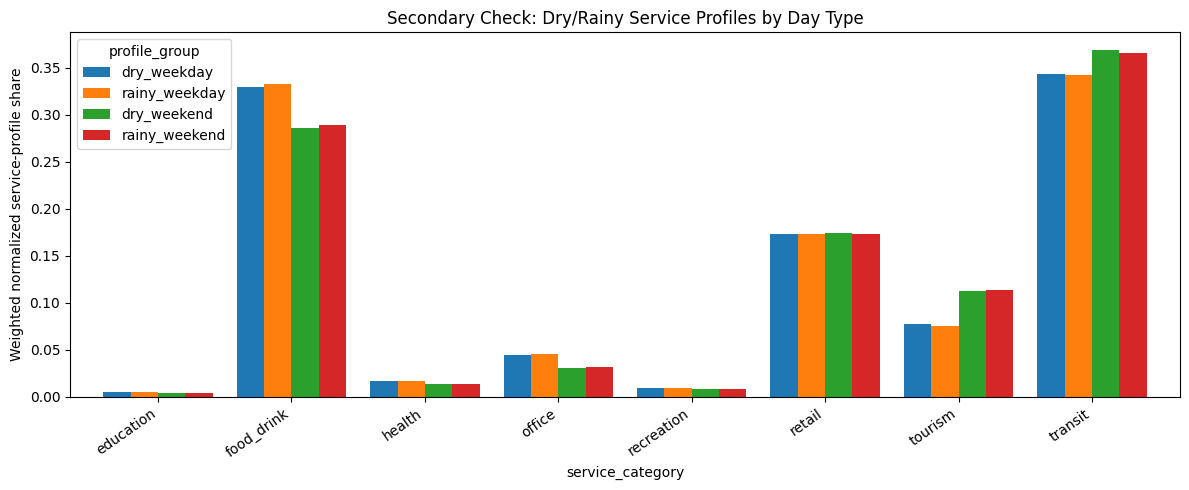

Figure interpretation: This chart checks whether rain changes the weekday/weekend service profile. The weather effect should be interpreted as a secondary descriptive check, not as the main result.
Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\weather_rain_effect_service_profile.csv


Saved figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\weather_rain_effect_by_day_type.png


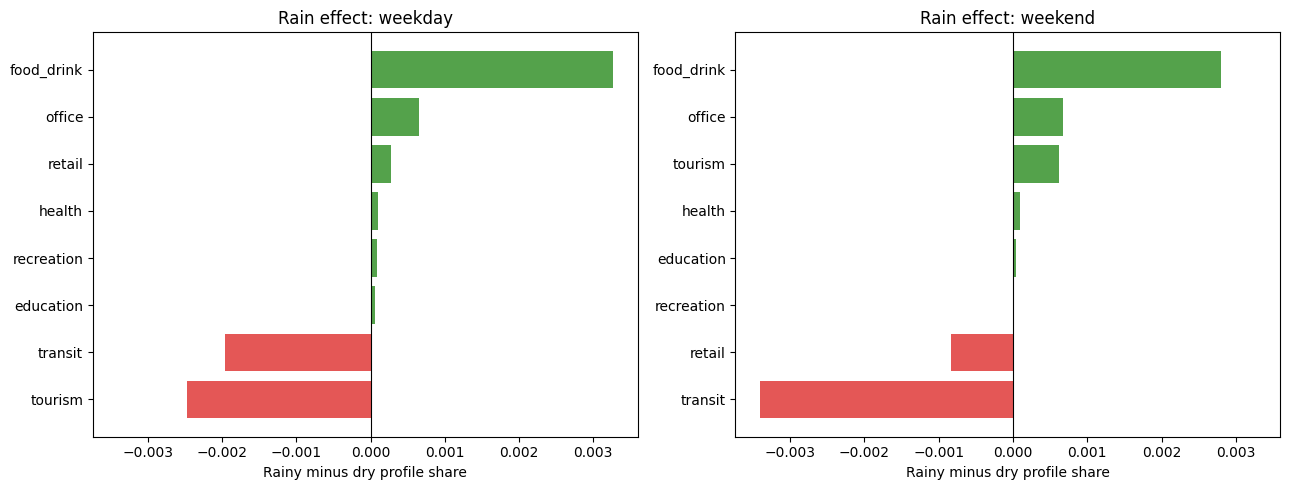

Figure interpretation: Positive values mean a service category is more represented on rainy days. The magnitudes are expected to be small because weather is measured daily rather than at exact trip time.


In [19]:
def weather_service_profiles(station_weather, service_df, condition_type="rain"):
    merged = station_weather[station_weather["condition_type"] == condition_type].copy()
    merged["end_station_name"] = merged["end_station_name"].astype(str).str.strip()
    service = service_df.copy()
    service["end_station_name"] = service["end_station_name"].astype(str).str.strip()
    service = service[service["end_station_name"].isin(set(profile_df_250["end_station_name"]))]
    merged = merged.merge(service, on="end_station_name", how="inner")
    service_cols = identify_service_columns(service, interpretable_only=True)
    if "total_services_interpretable" in merged.columns:
        merged = merged[merged["total_services_interpretable"] > 0].copy()
    rows = []
    for (day_type, condition_value), group in merged.groupby(["day_type", "condition_value"]):
        profile = compute_weighted_service_profile(group, service_cols, "return_count")
        for service_category, profile_value in profile.items():
            rows.append({
                "condition_type": condition_type,
                "day_type": day_type,
                "condition_value": condition_value,
                "profile_group": f"{condition_value}_{day_type}",
                "service_category": service_category,
                "profile_value": profile_value,
                "stations_used": group["end_station_name"].nunique(),
            })
    return pd.DataFrame(rows)


rain_service_profiles = weather_service_profiles(station_weather_counts, service_counts_250, condition_type="rain")
cold_service_profiles = weather_service_profiles(station_weather_counts, service_counts_250, condition_type="cold")
weather_service_profiles_all = pd.concat([rain_service_profiles, cold_service_profiles], ignore_index=True)
save_table(weather_service_profiles_all, "weather_service_profiles.csv")
save_table(rain_service_profiles, "weather_rain_service_profiles.csv")
save_table(cold_service_profiles, "weather_cold_service_profiles.csv")

rain_pivot = rain_service_profiles.pivot_table(index="service_category", columns="profile_group", values="profile_value", fill_value=0)
preferred_order = ["dry_weekday", "rainy_weekday", "dry_weekend", "rainy_weekend"]
rain_pivot = rain_pivot[[col for col in preferred_order if col in rain_pivot.columns]]
rain_pivot.plot(kind="bar", figsize=(12, 5), width=0.82)
plt.ylabel("Weighted normalized service-profile share")
plt.title("Secondary Check: Dry/Rainy Service Profiles by Day Type")
plt.xticks(rotation=35, ha="right")
save_figure("weather_dry_rainy_service_profiles.png")
plt.show()

print(
    "Figure interpretation: This chart checks whether rain changes the weekday/weekend service profile. "
    "The weather effect should be interpreted as a secondary descriptive check, not as the main result."
)

rain_effect_rows = []
for day_type in ["weekday", "weekend"]:
    dry_col = f"dry_{day_type}"
    rainy_col = f"rainy_{day_type}"
    if dry_col in rain_pivot.columns and rainy_col in rain_pivot.columns:
        diff = rain_pivot[rainy_col] - rain_pivot[dry_col]
        for service_category, value in diff.items():
            rain_effect_rows.append({"day_type": day_type, "service_category": service_category, "rainy_minus_dry": value})
rain_effect = pd.DataFrame(rain_effect_rows)
save_table(rain_effect, "weather_rain_effect_service_profile.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
for ax, day_type in zip(axes, ["weekday", "weekend"]):
    temp = rain_effect[rain_effect["day_type"] == day_type].sort_values("rainy_minus_dry")
    colors = np.where(temp["rainy_minus_dry"] >= 0, "#54A24B", "#E45756")
    ax.barh(temp["service_category"], temp["rainy_minus_dry"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Rain effect: {day_type}")
    ax.set_xlabel("Rainy minus dry profile share")
save_figure("weather_rain_effect_by_day_type.png")
plt.show()

print(
    "Figure interpretation: Positive values mean a service category is more represented on rainy days. "
    "The magnitudes are expected to be small because weather is measured daily rather than at exact trip time."
)


Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\validation_weather_effect_strength.csv


,day_type,rain_effect_l1
0,weekday,0.0089
1,weekend,0.0085


Saved figure: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\figures\final_clean\validation_weather_effect_strength.png


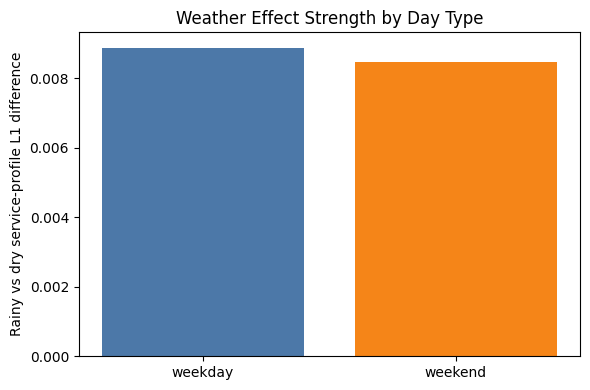

In [20]:
weather_effect_strength = rain_effect.groupby("day_type")["rainy_minus_dry"].apply(lambda values: float(np.abs(values).sum())).reset_index(name="rain_effect_l1")
save_table(weather_effect_strength, "validation_weather_effect_strength.csv")
display(weather_effect_strength)

plt.figure(figsize=(6, 4))
plt.bar(weather_effect_strength["day_type"], weather_effect_strength["rain_effect_l1"], color=["#4C78A8", "#F58518"])
plt.ylabel("Rainy vs dry service-profile L1 difference")
plt.title("Weather Effect Strength by Day Type")
save_figure("validation_weather_effect_strength.png")
plt.show()


**Weather secondary-check interpretation.**

- **Purpose:** Test whether rainy/dry grouping changes the destination-service profile.
- **Result:** Rainy-vs-dry L1 differences are small for both weekday and weekend.
- **Interpretation:** Weather should remain a secondary check. It does not drive the main conclusion about weekday/weekend destination-service environments.


## Validation Decision Summary

This table converts the validation results into final claims. It separates supported exploratory findings from unsupported or weak claims.


In [21]:
def metric_value(table, metric):
    return float(table.loc[table["metric"] == metric, "value"].iloc[0])

label_shuffle_p = metric_value(shuffle_result, "p_value")
station_demand_p = metric_value(station_demand_randomization_results, "p_value")
station_service_p = metric_value(permutation_result, "p_value")
weather_l1_max = float(weather_effect_strength["rain_effect_l1"].max())

validation_overview = pd.DataFrame([
    {
        "validation_test": "Top20 overlap baseline",
        "question_answered": "Do weekday/weekend high-volume end stations differ spatially?",
        "null_or_comparison": "Weekday Top20 vs weekend Top20 station sets",
        "output_file": "top20_overlap_summary.csv",
        "key_result": "Top20 overlap = 55%",
        "interpretation": "High-volume weekday and weekend destinations are not identical.",
        "decision": "supported spatial difference baseline",
    },
    {
        "validation_test": "Normalized heatmap / difference map",
        "question_answered": "Where are weekday/weekend station-share differences located?",
        "null_or_comparison": "weekday_station_share vs weekend_station_share",
        "output_file": "station_weekday_weekend_share_difference.csv",
        "key_result": "Lakefront/tourism stations are relatively weekend-oriented; downtown commute stations are relatively weekday-oriented.",
        "interpretation": "Heatmaps motivate OSM service profiling but do not prove rider intent.",
        "decision": "supported as exploratory spatial evidence",
    },
    {
        "validation_test": "Label shuffle test",
        "question_answered": "Is the overall service-profile difference larger than random day-type labels?",
        "null_or_comparison": "Shuffle weekday/weekend labels",
        "output_file": "shuffle_test_results.csv",
        "key_result": f"p = {label_shuffle_p:.4f}",
        "interpretation": "Does not support overall statistical significance at 0.05 under this null.",
        "decision": "not supported as overall significance",
    },
    {
        "validation_test": "Station-demand randomization test",
        "question_answered": "Can station totals plus global weekday share explain the profile difference?",
        "null_or_comparison": "Binomial weekday/weekend assignment preserving station totals",
        "output_file": "station_demand_randomization_results.csv",
        "key_result": f"p = {station_demand_p:.4f}",
        "interpretation": "The observed difference is larger than expected under a station-total-preserving global-share random assignment; this supports structured temporal allocation, not causality.",
        "decision": "supported as structure under this null; not causal evidence",
    },
    {
        "validation_test": "Station-service permutation test",
        "question_answered": "Is real station-service pairing more structured than random service assignment?",
        "null_or_comparison": "Shuffle service vectors across stations",
        "output_file": "station_service_permutation_results.csv",
        "key_result": f"p = {station_service_p:.4f}",
        "interpretation": "Real station-service pairing is more structured than random assignment; not causal proof.",
        "decision": "supported structured pairing",
    },
    {
        "validation_test": "Bootstrap confidence intervals",
        "question_answered": "Are service-level directions stable?",
        "null_or_comparison": "Resample stations",
        "output_file": "bootstrap_service_category_fdr.csv",
        "key_result": "Stable categories include tourism, food_drink, office, and health before/with stability checks.",
        "interpretation": "Category directions are stability evidence, not causal tests.",
        "decision": "partly supported by category",
    },
    {
        "validation_test": "Leave-one-station-out influence test",
        "question_answered": "Is the result driven by one station?",
        "null_or_comparison": "Remove one station at a time",
        "output_file": "leave_one_station_out_influence.csv",
        "key_result": "Top influential stations listed in top_influential_stations.csv",
        "interpretation": "Shows whether tourism or food/drink directions depend on dominant stations.",
        "decision": "influence check reported",
    },
    {
        "validation_test": "OSM coverage bias diagnostics",
        "question_answered": "Could missing OSM coverage bias the result?",
        "null_or_comparison": "Covered vs uncovered stations",
        "output_file": "osm_coverage_bias_summary.csv",
        "key_result": "Top100 covered return share = 63.63%",
        "interpretation": "Coverage is incomplete and must be treated as a limitation.",
        "decision": "limitation documented",
    },
    {
        "validation_test": "Top-K x Radius sensitivity grid",
        "question_answered": "Do Top-K and radius choices change the direction?",
        "null_or_comparison": "Top20/50/100 x 100m/250m/500m",
        "output_file": "topk_radius_sensitivity_grid.csv",
        "key_result": "Food/drink remains weekday-oriented; tourism is often weekend-oriented.",
        "interpretation": "Direction is partly stable, effect size is scale-sensitive.",
        "decision": "partly stable",
    },
    {
        "validation_test": "Service vector normalization sensitivity",
        "question_answered": "Does vector construction change the result?",
        "null_or_comparison": "Composition vs intensity vs binary presence",
        "output_file": "service_vector_normalization_sensitivity.csv",
        "key_result": "Compared across three profile variants.",
        "interpretation": "Shows whether conclusion depends on station-vector normalization.",
        "decision": "method sensitivity reported",
    },
    {
        "validation_test": "Category inclusion sensitivity",
        "question_answered": "Do other_amenity or transit choices change the result?",
        "null_or_comparison": "Interpretable, plus other, without transit, without transit plus other",
        "output_file": "category_inclusion_sensitivity.csv",
        "key_result": "Category sets compared.",
        "interpretation": "Keeps other_amenity out of the main claim and checks transit influence.",
        "decision": "category sensitivity reported",
    },
    {
        "validation_test": "Weather secondary check",
        "question_answered": "Are rainy/dry effects strong enough to drive the main conclusion?",
        "null_or_comparison": "Rainy vs dry service profiles",
        "output_file": "validation_weather_effect_strength.csv",
        "key_result": f"max rain-effect L1 = {weather_l1_max:.4f}",
        "interpretation": "Weather effect is small and remains secondary.",
        "decision": "weak / secondary only",
    },
])
save_table(validation_overview, "validation_overview.csv")
display(validation_overview)

final_validation_decision_summary = pd.DataFrame([
    {
        "claim": "Weekday/weekend high-volume end stations differ spatially.",
        "evidence_used": "Top20 overlap, normalized heatmaps, weekend-minus-weekday difference map",
        "validation_result": "Top20 overlap is 55%; heatmaps show relative spatial differences.",
        "decision": "supported",
        "final_wording": "Weekday and weekend high-volume destination patterns differ spatially.",
    },
    {
        "claim": "Weekend-weighted destinations are more tourism-associated.",
        "evidence_used": "Top100 profile, bootstrap CI, Top-K sensitivity, Top-K x Radius grid",
        "validation_result": "Tourism is weekend-oriented in the main profile and checked across robustness tests.",
        "decision": "supported as exploratory association if stable in sensitivity outputs",
        "final_wording": "Weekend-weighted destinations are more associated with tourism in the covered high-volume station set.",
    },
    {
        "claim": "Weekday-weighted destinations are more food_drink-associated.",
        "evidence_used": "Top100 profile, bootstrap CI, Top-K sensitivity, Top-K x Radius grid",
        "validation_result": "Food/drink is weekday-oriented in the main profile and sensitivity checks.",
        "decision": "supported as exploratory association",
        "final_wording": "Weekday-weighted destinations are more associated with food/drink service environments.",
    },
    {
        "claim": "Weekday-weighted destinations are more office-associated.",
        "evidence_used": "Top100 profile and bootstrap CI",
        "validation_result": "Office is weekday-oriented with a smaller but stable direction.",
        "decision": "supported but smaller effect",
        "final_wording": "Office association is weekday-oriented but smaller than food/drink.",
    },
    {
        "claim": "Transit is weekend-oriented.",
        "evidence_used": "Descriptive Top100 result and bootstrap CI",
        "validation_result": "Transit is positive descriptively but bootstrap CI crosses zero.",
        "decision": "interpret cautiously",
        "final_wording": "Transit appears weekend-oriented descriptively, but this direction is less stable.",
    },
    {
        "claim": "Overall service-profile difference is statistically significant.",
        "evidence_used": "Label shuffle p-value",
        "validation_result": f"label shuffle p = {label_shuffle_p:.4f}",
        "decision": "not supported under label-shuffle null",
        "final_wording": "Do not claim overall statistical significance under the label-shuffle null.",
    },
    {
        "claim": "Station totals plus the global weekday share fully explain the service-profile difference.",
        "evidence_used": "Station-demand randomization p-value",
        "validation_result": f"station-demand randomization p = {station_demand_p:.4f}",
        "decision": "not supported under this null",
        "final_wording": "The observed weekday/weekend allocation is more structured than station totals plus global weekday share, but this does not prove OSM services cause behavior.",
    },
    {
        "claim": "Real station-service pairing is structured.",
        "evidence_used": "Station-service permutation p-value",
        "validation_result": f"station-service permutation p = {station_service_p:.4f}",
        "decision": "supported",
        "final_wording": "The observed station-service pairing is more structured than random service assignment.",
    },
    {
        "claim": "Weather meaningfully changes destination-service profiles.",
        "evidence_used": "Rain-effect L1 score",
        "validation_result": f"max rain-effect L1 = {weather_l1_max:.4f}",
        "decision": "weak / secondary only",
        "final_wording": "Rainy/dry effects are small and should remain secondary.",
    },
])
save_table(final_validation_decision_summary, "final_validation_decision_summary.csv")
display(final_validation_decision_summary)


Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\validation_overview.csv


,validation_test,question_answered,null_or_comparison,output_file,key_result,interpretation,decision
0,Top20 overlap baseline,Do weekday/weekend high-volume end stations di...,Weekday Top20 vs weekend Top20 station sets,top20_overlap_summary.csv,Top20 overlap = 55%,High-volume weekday and weekend destinations a...,supported spatial difference baseline
1,Normalized heatmap / difference map,Where are weekday/weekend station-share differ...,weekday_station_share vs weekend_station_share,station_weekday_weekend_share_difference.csv,Lakefront/tourism stations are relatively week...,Heatmaps motivate OSM service profiling but do...,supported as exploratory spatial evidence
2,Label shuffle test,Is the overall service-profile difference larg...,Shuffle weekday/weekend labels,shuffle_test_results.csv,p = 0.2657,Does not support overall statistical significa...,not supported as overall significance
3,Station-demand randomization test,Can station totals plus global weekday share e...,Binomial weekday/weekend assignment preserving...,station_demand_randomization_results.csv,p = 0.0010,The observed difference is larger than expecte...,supported as structure under this null; not ca...
4,Station-service permutation test,Is real station-service pairing more structure...,Shuffle service vectors across stations,station_service_permutation_results.csv,p = 0.0010,Real station-service pairing is more structure...,supported structured pairing
5,Bootstrap confidence intervals,Are service-level directions stable?,Resample stations,bootstrap_service_category_fdr.csv,"Stable categories include tourism, food_drink,...","Category directions are stability evidence, no...",partly supported by category
6,Leave-one-station-out influence test,Is the result driven by one station?,Remove one station at a time,leave_one_station_out_influence.csv,Top influential stations listed in top_influen...,Shows whether tourism or food/drink directions...,influence check reported
7,OSM coverage bias diagnostics,Could missing OSM coverage bias the result?,Covered vs uncovered stations,osm_coverage_bias_summary.csv,Top100 covered return share = 63.63%,Coverage is incomplete and must be treated as ...,limitation documented
8,Top-K x Radius sensitivity grid,Do Top-K and radius choices change the direction?,Top20/50/100 x 100m/250m/500m,topk_radius_sensitivity_grid.csv,Food/drink remains weekday-oriented; tourism i...,"Direction is partly stable, effect size is sca...",partly stable
9,Service vector normalization sensitivity,Does vector construction change the result?,Composition vs intensity vs binary presence,service_vector_normalization_sensitivity.csv,Compared across three profile variants.,Shows whether conclusion depends on station-ve...,method sensitivity reported


Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\final_validation_decision_summary.csv


,claim,evidence_used,validation_result,decision,final_wording
0,Weekday/weekend high-volume end stations diffe...,"Top20 overlap, normalized heatmaps, weekend-mi...",Top20 overlap is 55%; heatmaps show relative s...,supported,Weekday and weekend high-volume destination pa...
1,Weekend-weighted destinations are more tourism...,"Top100 profile, bootstrap CI, Top-K sensitivit...",Tourism is weekend-oriented in the main profil...,supported as exploratory association if stable...,Weekend-weighted destinations are more associa...
2,Weekday-weighted destinations are more food_dr...,"Top100 profile, bootstrap CI, Top-K sensitivit...",Food/drink is weekday-oriented in the main pro...,supported as exploratory association,Weekday-weighted destinations are more associa...
3,Weekday-weighted destinations are more office-...,Top100 profile and bootstrap CI,Office is weekday-oriented with a smaller but ...,supported but smaller effect,Office association is weekday-oriented but sma...
4,Transit is weekend-oriented.,Descriptive Top100 result and bootstrap CI,Transit is positive descriptively but bootstra...,interpret cautiously,Transit appears weekend-oriented descriptively...
5,Overall service-profile difference is statisti...,Label shuffle p-value,label shuffle p = 0.2657,not supported under label-shuffle null,Do not claim overall statistical significance ...
6,Station totals plus the global weekday share f...,Station-demand randomization p-value,station-demand randomization p = 0.0010,not supported under this null,The observed weekday/weekend allocation is mor...
7,Real station-service pairing is structured.,Station-service permutation p-value,station-service permutation p = 0.0010,supported,The observed station-service pairing is more s...
8,Weather meaningfully changes destination-servi...,Rain-effect L1 score,max rain-effect L1 = 0.0089,weak / secondary only,Rainy/dry effects are small and should remain ...


## Feedback Integration

This section documents how presentation feedback and rubric-related issues were integrated into the final analysis. The goal is not to add a separate new result, but to show how the final notebook responds to critiques about problem framing, pipeline completeness, spatial evidence, validation, and interpretation.

| Feedback or issue raised | How the final notebook addresses it | Evidence in this notebook |
|---|---|---|
| The project should be more than a simple weekday/weekend comparison. | The research question is reframed around destination-service environments, not only trip counts, duration, or distance. | Research Question and Hypothesis; Destination-Service Profiling Framework |
| The data pipeline should be explicit and reproducible. | The notebook documents filtering, temporal stratification, end-station aggregation, outlier handling, and saved outputs. | Experimental Setup; Cleaning and Preprocessing |
| Spatial results should show where patterns differ, not only table summaries. | Normalized weekday/weekend heatmaps and a weekend-minus-weekday difference map were added. | Spatial Destination Heatmaps |
| OSM matching should not rely only on station-name matching. | OSM service counts are refreshed from a local citywide POI cache using station coordinates and radius-based matching. | OSM Service Analysis for Top End Stations |
| Service categories need to be interpretable. | Service-category definitions are documented, and `other_amenity` is excluded from the main interpreted profile because it is heterogeneous. | OSM Service Analysis for Top End Stations; Destination-Service Profiling Framework |
| The main analysis should be more stable than a Top 20-only result. | The main service-profile analysis uses the Top 100 weekday/weekend union, with Top-K sensitivity checks for Top 20, Top 50, and Top 100. | Main OSM Service Profile Results; Influence, coverage, and method sensitivity checks |
| Validation should be stronger than a single shuffle test. | The final notebook includes label shuffle, station-demand randomization, station-service permutation, bootstrap confidence intervals, leave-one-station-out influence, OSM coverage diagnostics, radius sensitivity, Top-K sensitivity, normalization sensitivity, category sensitivity, and weather as a secondary check. | Validation; Validation Decision Summary |
| The conclusion should not overclaim statistical significance or causality. | The discussion states that label shuffle p = 0.2657 does not support overall significance under that null, and the conclusion frames results as exploratory associations rather than causal proof. | Discussion and Limitations; Conclusion |

The resulting final claim is narrower but stronger: weekday and weekend Divvy destination patterns differ spatially, and covered high-volume destination stations are associated with different nearby service environments. The evidence supports an exploratory association, not a causal claim.


## Discussion and Limitations

This project should be interpreted as an exploratory spatial mobility pipeline, not a causal model of rider intent.

**OSM coverage and high-volume subset limitation.** The main profile uses the Top 100 weekday/weekend union, where 75 of 129 stations have interpretable OSM profiles at 250m and those covered stations represent 63.63% of Top 100 union return counts. This is stronger than the original Top 20-only cache, but it is still not full-system coverage. OSM coverage diagnostics compare covered and uncovered stations, but missing coverage remains a limitation. Future work should expand to all stations, refresh OSM coverage directly, report return-count coverage, and test finer POI categories.

**Validation limitation.** The label shuffle test has p = 0.2657, so the overall service-profile difference is not statistically significant at the 0.05 level under that null model. The station-demand randomization test rules out a simple station-total plus global-share allocation null, and the station-service permutation test, bootstrap intervals, leave-one-station-out checks, and sensitivity grids provide a broader defense system. These tests can support structured and partly stable service-level patterns, especially `tourism`, `food_drink`, and `office`, but they do not prove that OSM services caused rider behavior. Future work could add more stations, time-of-day stratification, temporal holdout by quarter, and more precise land-use categories.

**Destination proxy limitation.** End station is only a destination proxy. Riders may walk after returning a bike, so nearby OSM services do not prove the rider's actual activity. The 250m radius and Top 100 scope are modeling choices, and sensitivity tests show that scale and category definitions can affect results. Daily weather labels also do not capture exact trip-time weather. Stronger future work would use network distance, trip-level weather, richer land-use data, surveys, or GPS trajectories if available.


## Conclusion

This project should be interpreted as an exploratory spatial association, not a causal claim.

The spatial baselines and normalized heatmaps show that weekday and weekend high-volume Divvy end-station patterns differ in Chicago. The Top 100 coordinate-based OSM service profile suggests that weekend-weighted destinations are more associated with `tourism`, while weekday-weighted destinations are more associated with `food_drink` and `office`.

Validation is mixed but defendable. The label shuffle test does not support overall statistical significance at the 0.05 level, so the final claim should stay cautious. However, the station-demand randomization test, station-service permutation test, bootstrap intervals, leave-one-station-out checks, Top-K sensitivity, radius sensitivity, normalization sensitivity, and category sensitivity indicate that several service-level directions are structured and partly stable.

The final interpretation is that weekday and weekend Divvy destination patterns differ spatially and are associated with different nearby urban service environments, within the limits of end-station proxy analysis, incomplete OSM coverage, and modeling choices such as radius and Top-K scope.


In [22]:
radius_services = ", ".join(
    f"{int(row.radius_m)}m: weekend={row.most_weekend_oriented_service}, weekday={row.most_weekday_oriented_service}"
    for _, row in radius_sensitivity.iterrows()
)
topk_services = ", ".join(
    f"Top {int(row.topk_union)}: weekend={row.most_weekend_oriented_service}, weekday={row.most_weekday_oriented_service}"
    for _, row in topk_sensitivity.iterrows()
)
stable_positive = (
    bootstrap_ci.loc[
        bootstrap_ci["ci_excludes_zero"] & (bootstrap_ci["observed_weekend_minus_weekday"] > 0)
    ]
    .sort_values("observed_weekend_minus_weekday", ascending=False)["service_category"]
    .tolist()
)
stable_negative = (
    bootstrap_ci.loc[
        bootstrap_ci["ci_excludes_zero"] & (bootstrap_ci["observed_weekend_minus_weekday"] < 0)
    ]
    .sort_values("observed_weekend_minus_weekday", ascending=True)["service_category"]
    .tolist()
)
stable_bootstrap = (
    f"Weekend-oriented stable: {', '.join(stable_positive) if stable_positive else 'none'}; "
    f"Weekday-oriented stable: {', '.join(stable_negative) if stable_negative else 'none'}"
)
weather_effect_summary = weather_effect_strength.sort_values("rain_effect_l1", ascending=False).iloc[0]

final_summary = pd.DataFrame([
    {
        "result_item": "Main weekday/weekend service-profile difference",
        "value": real_difference_score,
        "interpretation": f"L1 difference between weighted weekday and weekend OSM service profiles for covered Top {MAIN_PROFILE_TOP_K} union stations, excluding other_amenity.",
    },
    {
        "result_item": "Label shuffle p-value",
        "value": float(shuffle_p_value),
        "interpretation": "If this is not below 0.05, do not claim the overall profile difference is statistically significant under the label-shuffle null.",
    },

    {
        "result_item": "Station-demand randomization p-value",
        "value": float(demand_randomization_p_value),
        "interpretation": "Tests whether station totals plus global weekday share can explain the profile difference; it does not prove OSM services explain behavior.",
    },
    {
        "result_item": "Station-service permutation p-value",
        "value": float(permutation_p_value),
        "interpretation": "Tests whether real station-service pairing is more structured than random service-vector assignment.",
    },
    {
        "result_item": "Bootstrap stable service directions",
        "value": stable_bootstrap,
        "interpretation": "Service categories whose bootstrap confidence interval for weekend-minus-weekday excludes zero, reported with direction.",
    },
    {
        "result_item": "Radius sensitivity result",
        "value": radius_services,
        "interpretation": "Compares strongest service directions at 100m, 250m, and 500m.",
    },
    {
        "result_item": "Top-K sensitivity result",
        "value": topk_services,
        "interpretation": "Compares strongest service directions for Top 20, Top 50, and Top 100 union sets.",
    },
    {
        "result_item": "Key weather effect",
        "value": f"{weather_effect_summary.day_type}: {weather_effect_summary.rain_effect_l1:.4f}",
        "interpretation": "Day type with the stronger rainy-vs-dry service-profile shift. Weather remains a secondary check.",
    },
])
save_table(final_summary, "final_results_summary.csv")
display(final_summary)


Saved table: C:\Users\peter\OneDrive\Documents\GitHub\pf\CSC588B_Project_Code\outputs\final_clean\final_results_summary.csv


,result_item,value,interpretation
0,Main weekday/weekend service-profile difference,0.1231,L1 difference between weighted weekday and wee...
1,Label shuffle p-value,0.2657,"If this is not below 0.05, do not claim the ov..."
2,Station-demand randomization p-value,0.0010,Tests whether station totals plus global weekd...
3,Station-service permutation p-value,0.0010,Tests whether real station-service pairing is ...
4,Bootstrap stable service directions,Weekend-oriented stable: tourism; Weekday-orie...,Service categories whose bootstrap confidence ...
5,Radius sensitivity result,"100m: weekend=transit, weekday=food_drink, 250...","Compares strongest service directions at 100m,..."
6,Top-K sensitivity result,"Top 20: weekend=tourism, weekday=food_drink, T...",Compares strongest service directions for Top ...
7,Key weather effect,weekday: 0.0089,Day type with the stronger rainy-vs-dry servic...
